<a href="https://colab.research.google.com/github/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre/blob/main/Modelo_N1_oportunidad_potencial_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **MODELO 1 — RESERVAS CANCELADAS & PROPENSIÓN A CANCELACIÓN PROBLEMÁTICA**

### Cargue de la Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [ ]:
# Para clonar un repositorio de GitHub
# Reemplaza 'TU_URL_DEL_REPOSITORIO' con la URL real de tu repositorio.
!git clone https://github.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre.git

print("https://github.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre.git")

Cloning into 'Trabajo-de-Grado_Hotel_Portoalegre'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 54 (delta 32), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 9.42 MiB | 12.50 MiB/s, done.
Resolving deltas: 100% (32/32), done.
https://github.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre.git


In [ ]:
file_path = '/content/Trabajo-de-Grado_Hotel_Portoalegre/reservas_canceladas_2026-03-18.xls'

try:
    # Try to read the file as an HTML table
    dfs = pd.read_html(file_path, encoding='utf-8')
    if dfs:
        df = dfs[0] # Assuming the first table is the one we want
        print(f"Archivo '{file_path}' cargado exitosamente como HTML.")
    else:
        print(f"No se encontraron tablas HTML en el archivo '{file_path}'.")
except Exception as e:
    print(f"Error al cargar el archivo como HTML: {e}")

Archivo '/content/Trabajo-de-Grado_Hotel_Portoalegre/reservas_canceladas_2026-03-18.xls' cargado exitosamente como HTML.


In [ ]:
display(df.head())

,ID de la reserva,Fecha cancelación,Habitación,huésped,Tipo doc,Documento,Entrada,Salida,Canal,Cancelada por,Fecha creación,Creada por,Motivo,Descripción,Total de la reserva
0,19626696,18/03/2026 15:18:18,Doble | Doble 25,Aguilar Lina,NaN,NaN,24/03/2026,28/03/2026,Booking.com,Lobbybookings,18/03/2026 11:33:13,Lobbybookings,Otras,Cancelación automática por Lobbybookings,"COP 880,304.00"
1,16908166,18/03/2026 11:55:26,Vista al mar | Cuadruple 15 +,GUZMAN LOZANO DIANA MILENA,C.C,52932239,20/03/2026,23/03/2026,Asesor comercial hotel,Comercial,12/08/2025 11:17:44,Comercial,Cancelación oportuna del cliente,cancelacion oportuna,"COP 1,116,000.00"
2,19614470,18/03/2026 02:00:04,Doble | Doble 11,Peña Guevara Nikol Tatiana,C.C,1020740136,24/03/2026,25/03/2026,Booking Engine,Booking Engine,17/03/2026 13:30:51,Booking Engine,Pago rechazado,NaN,"COP 223,529.00"
3,19614469,18/03/2026 02:00:03,Doble | Doble 39,Peña Guevara Nikol Tatiana,C.C,1020740136,20/03/2026,24/03/2026,Booking Engine,Booking Engine,17/03/2026 13:30:51,Booking Engine,Pago rechazado,NaN,"COP 1,281,427.00"
4,19620127,17/03/2026 19:14:20,Doble | Doble 13,Perez Camilo,NaN,1102841086,27/03/2026,29/03/2026,Booking Engine,Booking Engine,17/03/2026 19:09:43,Booking Engine,Pago rechazado,NaN,"COP 609,495.00"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3558 entries, 0 to 3557
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID de la reserva     3558 non-null   object
 1   Fecha cancelación    3558 non-null   object
 2   Habitación           3558 non-null   object
 3   huésped              3558 non-null   object
 4   Tipo doc             2249 non-null   object
 5   Documento            2918 non-null   object
 6   Entrada              3558 non-null   object
 7   Salida               3558 non-null   object
 8   Canal                3286 non-null   object
 9   Cancelada por        3558 non-null   object
 10  Fecha creación       3558 non-null   object
 11  Creada por           3558 non-null   object
 12  Motivo               3558 non-null   object
 13  Descripción          1290 non-null   object
 14  Total de la reserva  3111 non-null   object
dtypes: object(15)
memory usage: 417.1+ KB


## Análisis Exploratorio

### Revisión de datos nulos

In [ ]:
null = pd.DataFrame({'Null Values' : df.isna().sum(), 'Percentage Null Values' : (df.isna().sum()) / (df.shape[0]) * (100)})
null

,Null Values,Percentage Null Values
ID de la reserva,0,0.000000
Fecha cancelación,0,0.000000
Habitación,0,0.000000
huésped,0,0.000000
Tipo doc,1309,36.790332
Documento,640,17.987634
Entrada,0,0.000000
Salida,0,0.000000
Canal,272,7.644744
Cancelada por,0,0.000000


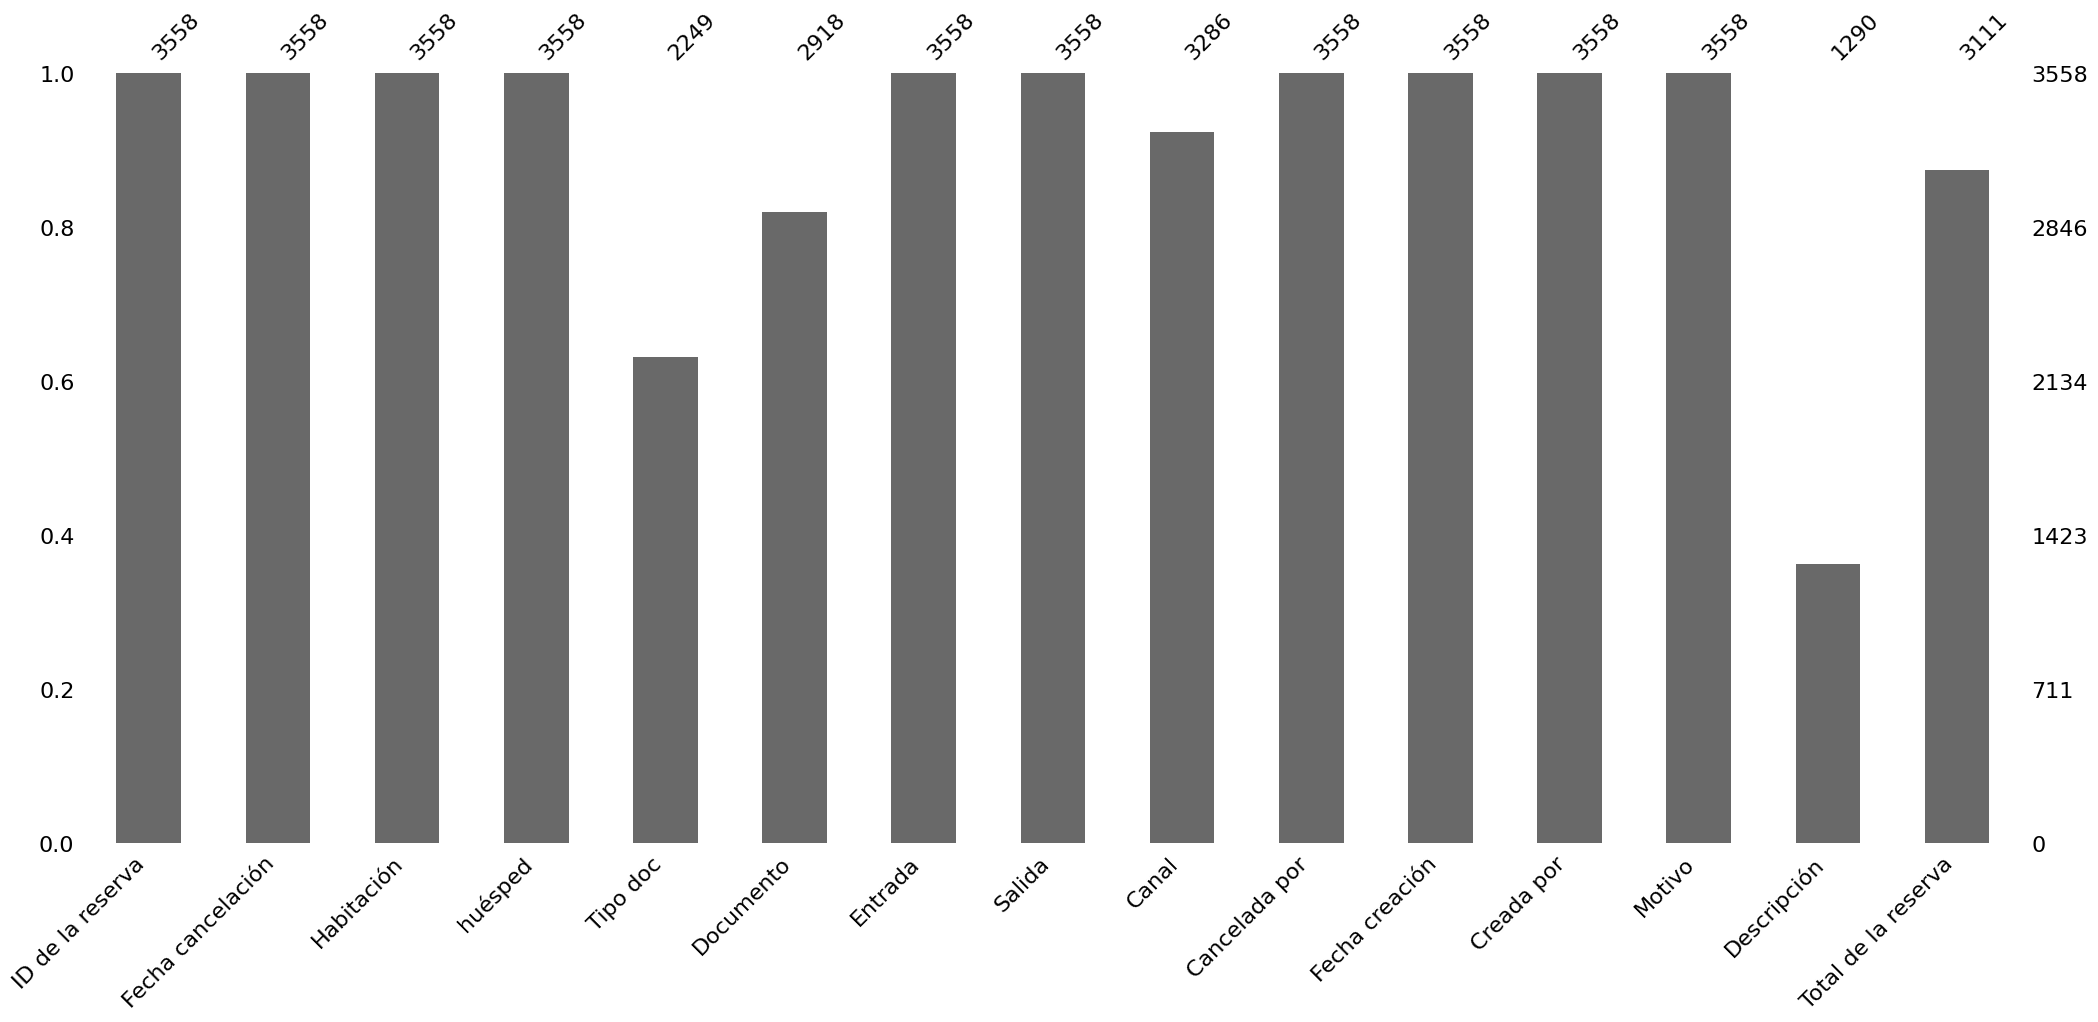

In [ ]:
msno.bar(df)
plt.show()

Variables con valores nulos:


,Variable,Nulos,% Nulos
13,Descripción,2268,63.74
4,Tipo doc,1309,36.79
5,Documento,640,17.99
14,Total de la reserva,447,12.56
8,Canal,272,7.64


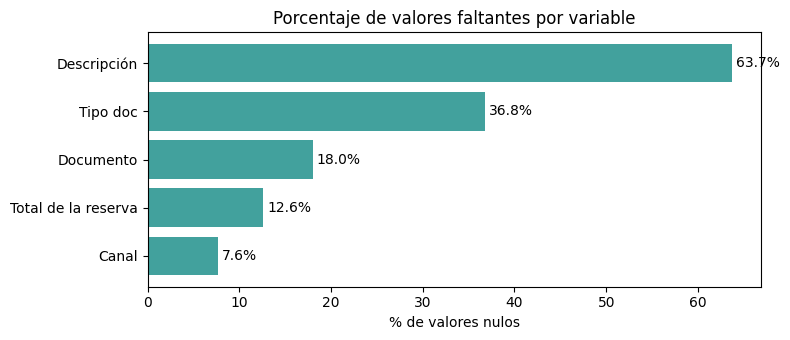

In [ ]:
nulos = df.isnull().sum().reset_index()
nulos.columns = ['Variable', 'Nulos']
nulos['% Nulos'] = (nulos['Nulos'] / len(df) * 100).round(2)
nulos = nulos[nulos['Nulos'] > 0].sort_values('% Nulos', ascending=False)

print('Variables con valores nulos:')
display(nulos)

PALETTE = sns.color_palette("viridis", n_colors=len(nulos))
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(nulos['Variable'], nulos['% Nulos'], color=PALETTE[2], alpha=0.85)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de valores faltantes por variable')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Distribución de la Variable Objetivo

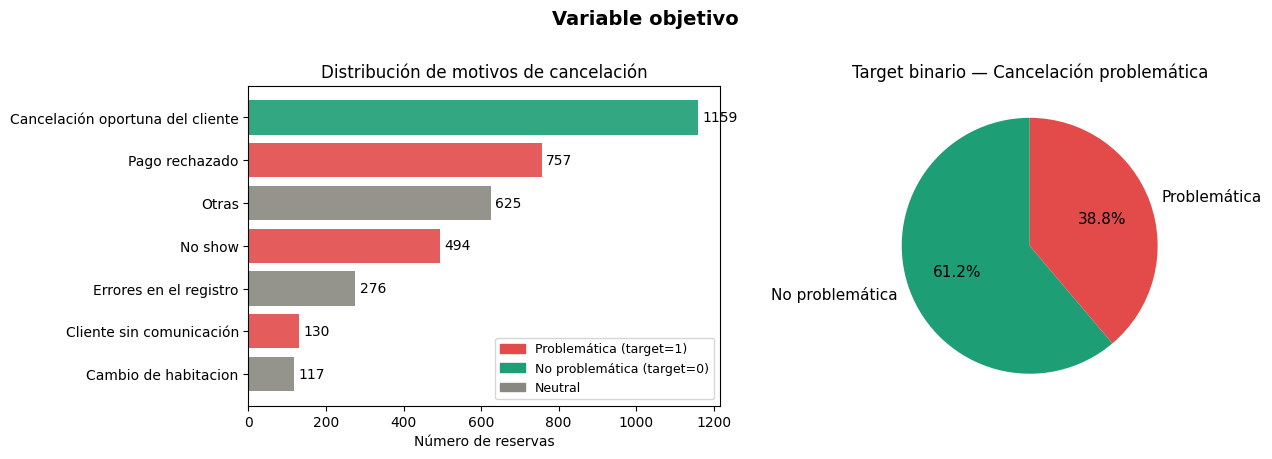


Cancelaciones problemáticas: 1,381 (38.8%)
Cancelaciones no problemáticas: 2,177 (61.2%)


In [ ]:
# Distribucion de Variable Objetivo
motivo_cnt = df['Motivo'].value_counts()

colores_motivo = [
    '#1D9E75',  # Cancelación oportuna  → no problemática
    '#E24B4A',  # Pago rechazado        → problemática
    '#888780',  # Otras
    '#E24B4A',  # No show               → problemática
    '#888780',  # Errores en registro
    '#E24B4A',  # Sin comunicación      → problemática
    '#888780',  # Cambio de habitación
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bars = axes[0].barh(motivo_cnt.index, motivo_cnt.values, color=colores_motivo, alpha=0.9)
axes[0].bar_label(bars, padding=3, fontsize=10)
axes[0].set_title('Distribución de motivos de cancelación')
axes[0].invert_yaxis()
axes[0].set_xlabel('Número de reservas')

from matplotlib.patches import Patch
leyenda = [Patch(color='#E24B4A', label='Problemática (target=1)'),
           Patch(color='#1D9E75', label='No problemática (target=0)'),
           Patch(color='#888780', label='Neutral')]
axes[0].legend(handles=leyenda, fontsize=9, loc='lower right')

# Target binario
target_temp = df['Motivo'].isin(['No show', 'Pago rechazado', 'Cliente sin comunicación'])
tc = target_temp.value_counts()
axes[1].pie(
    tc.values, labels=['No problemática', 'Problemática'],
    colors=['#1D9E75', '#E24B4A'], autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 11}
)
axes[1].set_title('Target binario — Cancelación problemática')

plt.suptitle('Variable objetivo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'\nCancelaciones problemáticas: {target_temp.sum():,} ({target_temp.mean()*100:.1f}%)')
print(f'Cancelaciones no problemáticas: {(~target_temp).sum():,} ({(~target_temp).mean()*100:.1f}%)')

### Parsear Fechas

In [ ]:
# Parsear Fechas
df = df.copy()
date_cols = ['Fecha cancelación', 'Entrada', 'Salida', 'Fecha creación']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

print('Fechas parseadas:')
print(df[date_cols].dtypes)
print('\nNulos en fechas:')
print(df[date_cols].isnull().sum())

Fechas parseadas:
Fecha cancelación    datetime64[ns]
Entrada              datetime64[ns]
Salida               datetime64[ns]
Fecha creación       datetime64[ns]
dtype: object

Nulos en fechas:
Fecha cancelación    0
Entrada              0
Salida               0
Fecha creación       0
dtype: int64


### Análisis Temporal de Cancelaciones

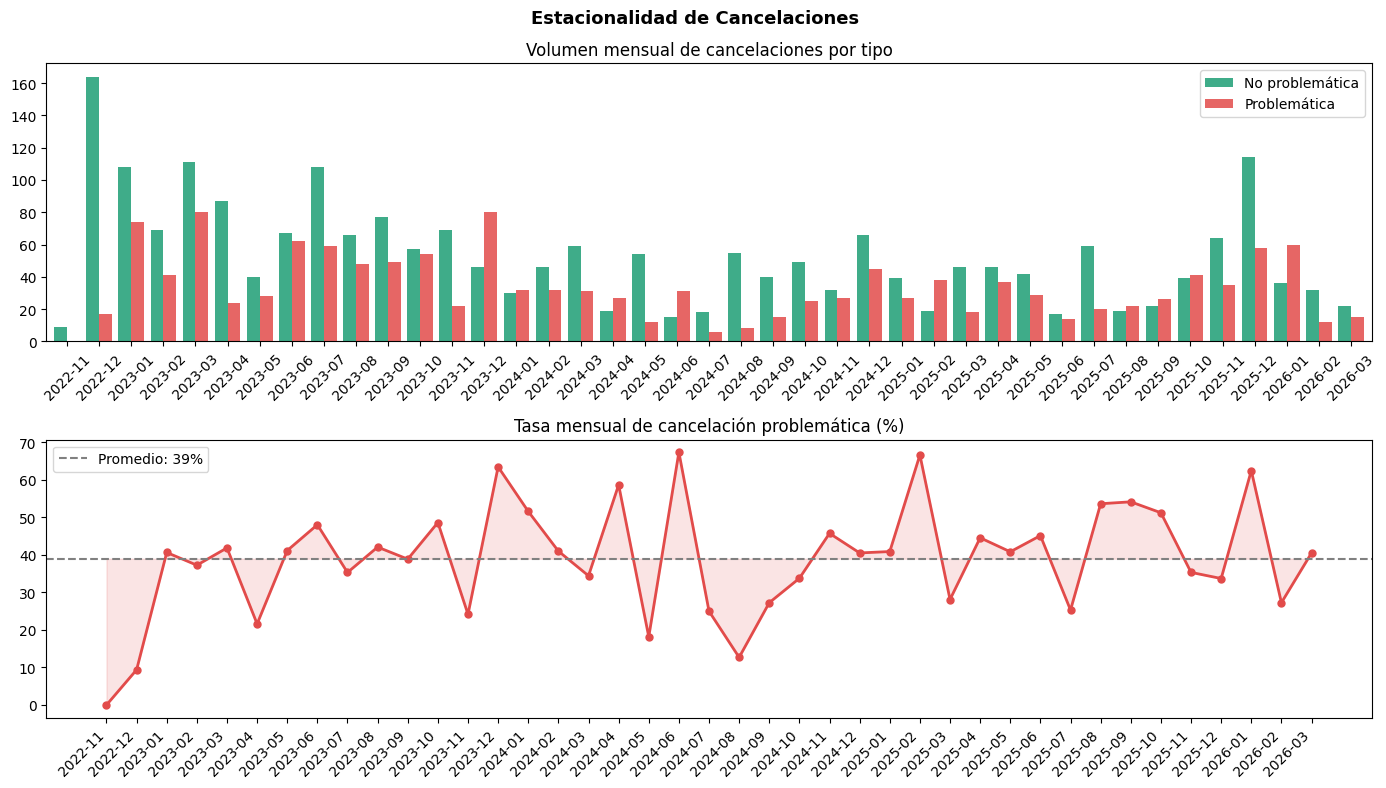

Top 5 timestamps con mayor concentración simultánea:
Fecha cancelación
2023-03-10 05:58:04    17
2022-12-06 12:19:39    14
2023-04-05 12:16:53    13
2026-02-17 14:25:11    13
2024-08-19 07:58:19    13
Name: count, dtype: int64

⚠ Registros en eventos masivos (≥10 simultáneos): 70
  → Deben excluirse del entrenamiento: son operaciones en lote del sistema
  → No representan comportamiento real del huésped


In [ ]:
date_cols = ['Fecha cancelación', 'Entrada', 'Salida', 'Fecha creación']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

df['mes_cancelacion_periodo'] = df['Fecha cancelación'].dt.to_period('M')

# Define the 'target' column based on cancellation motives
df['target'] = df['Motivo'].isin(['No show', 'Pago rechazado', 'Cliente sin comunicación']).astype(int)

monthly = df.groupby(['mes_cancelacion_periodo','target']).size().unstack(fill_value=0)
monthly.columns = ['No problemática','Problemática']
monthly.index = monthly.index.astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

monthly.plot(kind='bar', ax=axes[0], color=['#1D9E75','#E24B4A'], alpha=0.85, width=0.8)
axes[0].set_title('Volumen mensual de cancelaciones por tipo')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

tasa_mensual = monthly['Problemática'] / (monthly['No problemática'] + monthly['Problemática']) * 100
axes[1].plot(tasa_mensual.index, tasa_mensual.values, marker='o',
             color='#E24B4A', linewidth=2, markersize=5)
axes[1].axhline(tasa_mensual.mean(), color='gray', linestyle='--',
                label=f'Promedio: {tasa_mensual.mean():.0f}%')
axes[1].fill_between(range(len(tasa_mensual)), tasa_mensual.values,
                      tasa_mensual.mean(), alpha=0.15, color='#E24B4A')
axes[1].set_title('Tasa mensual de cancelación problemática (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xticks(range(len(tasa_mensual)))
axes[1].set_xticklabels(tasa_mensual.index, rotation=45, ha='right')
axes[1].legend()

plt.suptitle('Estacionalidad de Cancelaciones', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Detección de eventos masivos
timestamp_counts = df['Fecha cancelación'].value_counts().head(5)
print('Top 5 timestamps con mayor concentración simultánea:')
print(timestamp_counts)
mask_masivo = df['Fecha cancelación'].isin(timestamp_counts[timestamp_counts >= 10].index)
print(f'\n⚠ Registros en eventos masivos (≥10 simultáneos): {mask_masivo.sum()}')
print('  → Deben excluirse del entrenamiento: son operaciones en lote del sistema')
print('  → No representan comportamiento real del huésped')

### Análisis de Huéspedes Recurrentes

Top 15 huéspedes por volumen de cancelaciones:


,huésped,total_cancelaciones,cancelaciones_problematicas,tasa_problematica
710,HERRERA BURGOS DIEGO ALEJANDRO,75,0,0.000
1484,TORRES RAMIREZ DIANA PATRICIA,63,16,0.254
189,BURGOS SALGADO OLIVIA,56,0,0.000
5,AGENCIA DE VIAJES CHEC-IN SAMY ALVAREZ,50,0,0.000
534,FERRER OAORIO DIANA MILENA,49,1,0.020
472,Delgado ARISTIZABAL Lyda Marcela,48,0,0.000
810,LOURIDO VANEDIS,37,0,0.000
1137,PAIPILLA ANA ESPERANZA,28,0,0.000
406,Contacto: John Fabio Ramirez Ferry Travel Agencia,24,0,0.000
1108,Operador Cristina Arias Excursiones,22,0,0.000


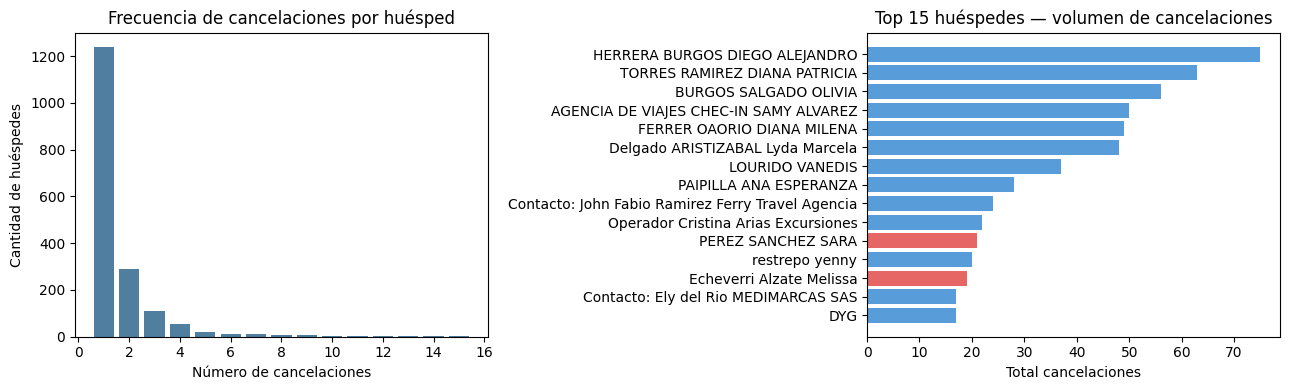

Huéspedes con >5 cancelaciones : 74
Huéspedes con >10 cancelaciones: 33

INTERPRETACIÓN: Alta recurrencia sugiere reservas especulativas o intermediarios
→ Se creará variable "cancelaciones_previas_huesped" en Feature Engineering


In [ ]:
huesped_cancel = df.groupby('huésped').agg(
    total_cancelaciones=('target','count'),
    cancelaciones_problematicas=('target','sum')
).reset_index()
huesped_cancel['tasa_problematica'] = (
    huesped_cancel['cancelaciones_problematicas'] / huesped_cancel['total_cancelaciones']
).round(3)
huesped_cancel = huesped_cancel.sort_values('total_cancelaciones', ascending=False)

print('Top 15 huéspedes por volumen de cancelaciones:')
display(huesped_cancel.head(15))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

freq = huesped_cancel['total_cancelaciones'].value_counts().sort_index()
axes[0].bar(freq.index[:15], freq.values[:15], color=PALETTE[1], alpha=0.85)
axes[0].set_title('Frecuencia de cancelaciones por huésped')
axes[0].set_xlabel('Número de cancelaciones')
axes[0].set_ylabel('Cantidad de huéspedes')

top15 = huesped_cancel.head(15)
colores_h = ['#E24B4A' if t > 0.5 else '#3B8BD4' for t in top15['tasa_problematica']]
axes[1].barh(top15['huésped'], top15['total_cancelaciones'], color=colores_h, alpha=0.85)
axes[1].set_title('Top 15 huéspedes — volumen de cancelaciones')
axes[1].invert_yaxis()
axes[1].set_xlabel('Total cancelaciones')

plt.tight_layout()
plt.show()

print(f'Huéspedes con >5 cancelaciones : {(huesped_cancel["total_cancelaciones"]>5).sum()}')
print(f'Huéspedes con >10 cancelaciones: {(huesped_cancel["total_cancelaciones"]>10).sum()}')
print()
print('INTERPRETACIÓN: Alta recurrencia sugiere reservas especulativas o intermediarios')
print('→ Se creará variable "cancelaciones_previas_huesped" en Feature Engineering')

## Feature Engineering

| Variable | Lógica de negocio hotelera |
|---|---|
| `noches_reserva` | Estadías largas tienen perfil de riesgo diferente (corporativo vs. turista fin de semana) |
| `dias_hasta_entrada` | Cancelaciones tardías generan mayor costo de oportunidad al no poder reasignar |
| `dias_anticipacion_cancelacion` | Alta anticipación sugiere reserva especulativa sin compromiso real |
| `es_fin_de_semana` | Estacionalidad semanal: principal driver de demanda en el Golfo de Morrosquillo |
| `hora_cancelacion` | Discrimina cancelaciones manuales (9–18h) de automáticas del Booking Engine (noche) |
| `mes_entrada` | Captura estacionalidad anual: jun–jul y dic–ene concentran mayor riesgo |
| `cancelaciones_previas_huesped` |historial por titular como proxy de reserva especulativa |
| `score riesgo por canal` |Se construye una variable que incorpora conocimiento de dominio|
| `Temporada` |Se incorpora `temporada` / `es_temporada_alta` como feature predictora y como dimensión|

In [ ]:
df['noches_reserva'] = (df['Salida'] - df['Entrada']).dt.days
df['dias_hasta_entrada'] = (df['Entrada'] - df['Fecha cancelación']).dt.days
df['dias_anticipacion_cancelacion'] = (df['Fecha cancelación'] - df['Fecha creación']).dt.days
df['mes_entrada'] = df['Entrada'].dt.month
df['dia_semana_entrada'] = df['Entrada'].dt.dayofweek
df['es_fin_de_semana'] = df['dia_semana_entrada'].isin([4, 5, 6]).astype(int)
df['mes_creacion'] = df['Fecha creación'].dt.month
df['hora_cancelacion'] = df['Fecha cancelación'].dt.hour

# ── CORRECCIÓN: cumcount anticausal en lugar de transform('count') ────────────
# transform('count') usa TODOS los registros del huésped → leakage temporal
# cumcount() solo cuenta registros ANTERIORES al actual → correcto
df = df.sort_values('Fecha creación').reset_index(drop=True)
df['cancelaciones_previas_huesped'] = df.groupby('huésped').cumcount()

print('Variables derivadas creadas:')
nuevas = ['noches_reserva','dias_hasta_entrada','dias_anticipacion_cancelacion',
          'mes_entrada','dia_semana_entrada','es_fin_de_semana','mes_creacion',
          'hora_cancelacion','cancelaciones_previas_huesped']
display(df[nuevas].describe().round(2))
print('NOTA: cancelaciones_previas_huesped recalculada post-split en celda 36 para evitar leakage.')


Variables derivadas creadas:


,noches_reserva,dias_hasta_entrada,dias_anticipacion_cancelacion,mes_entrada,dia_semana_entrada,es_fin_de_semana,mes_creacion,hora_cancelacion,cancelaciones_previas_huesped
count,3558.00,3558.00,3558.00,3558.00,3558.00,3558.00,3558.00,3558.00,3558.00
mean,2.49,22.87,26.55,6.16,3.49,0.58,6.34,13.35,4.50
std,1.46,63.64,55.51,3.89,1.84,0.49,3.80,4.85,10.36
min,0.00,-348.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00
25%,1.00,-1.00,0.00,3.00,2.00,0.00,3.00,10.00,0.00
50%,2.00,7.00,2.00,6.00,4.00,1.00,6.00,13.00,0.00
75%,3.00,29.00,28.00,10.00,5.00,1.00,10.00,17.00,3.00
max,28.00,441.00,479.00,12.00,6.00,1.00,12.00,23.00,74.00


NOTA: cancelaciones_previas_huesped recalculada post-split en celda 36 para evitar leakage.


Score de riesgo por canal (SOLO VISUALIZACIÓN — se recalcula post-split):


,Canal,Tasa problemática (%),Score asignado
0,Booking Engine,91.6,3
1,Price Travel,75.0,3
2,WhatsApp pag web,47.2,3
3,WhatsApp Recepción,44.9,3
4,Venta pag web,36.8,3
5,Venta Catalina Restrepo,33.3,3
6,Hotel Portoalegre,27.4,3
7,Venta Sandra Ospina,27.4,2
8,Venta Directa x Vendedor,25.3,2
9,Booking.com,25.1,2


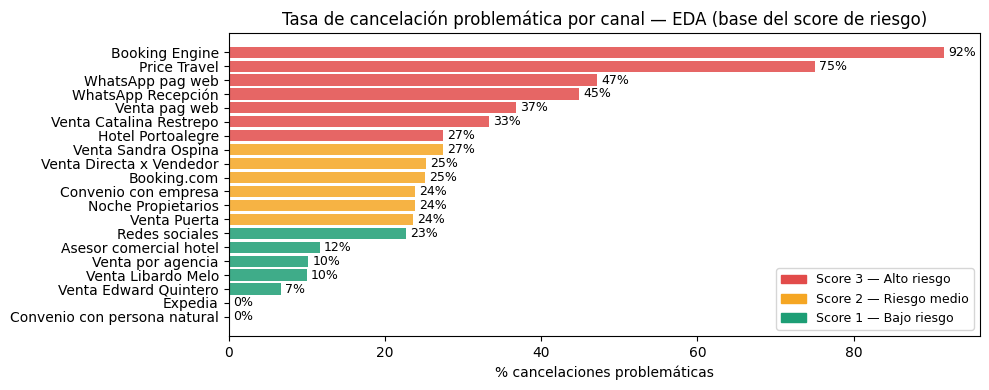

⚠ Esta versión es EXPLORATORIA. El score del modelo se calcula en celda 36 solo desde train.


In [ ]:
# ── NOTA IMPORTANTE — Score Riesgo por Canal ─────────────────────────────────
# Esta celda calcula el score_riesgo_canal sobre TODO el dataset para visualización
# exploratoria ÚNICAMENTE. El score que ingresa al modelo se recalcula exclusivamente
# desde train_df en la celda 36 (post-split) para evitar data leakage.

canal_riesgo = df.groupby('Canal')['target'].mean().sort_values(ascending=False)
q33 = canal_riesgo.quantile(0.33)
q66 = canal_riesgo.quantile(0.66)

def asignar_score_canal(tasa):
    if tasa >= q66: return 3
    elif tasa >= q33: return 2
    else: return 1

canal_score_map_viz = {c: asignar_score_canal(t) for c, t in canal_riesgo.items()}
canal_score_map_viz['Desconocido'] = 2
df['score_riesgo_canal'] = df['Canal'].map(canal_score_map_viz).fillna(2)

score_df = pd.DataFrame({
    'Canal': canal_riesgo.index,
    'Tasa problemática (%)': (canal_riesgo.values * 100).round(1),
    'Score asignado': [canal_score_map_viz[c] for c in canal_riesgo.index]
})
print('Score de riesgo por canal (SOLO VISUALIZACIÓN — se recalcula post-split):')
display(score_df)

fig, ax = plt.subplots(figsize=(10, 4))
colores_s = ['#E24B4A' if s==3 else '#F5A623' if s==2 else '#1D9E75'
             for s in score_df['Score asignado']]
bars = ax.barh(score_df['Canal'], score_df['Tasa problemática (%)'], color=colores_s, alpha=0.85)
ax.bar_label(bars, fmt='%.0f%%', padding=3, fontsize=9)
ax.invert_yaxis()
ax.set_title('Tasa de cancelación problemática por canal — EDA (base del score de riesgo)')
ax.set_xlabel('% cancelaciones problemáticas')
from matplotlib.patches import Patch
leg = [Patch(color='#E24B4A',label='Score 3 — Alto riesgo'),
       Patch(color='#F5A623',label='Score 2 — Riesgo medio'),
       Patch(color='#1D9E75',label='Score 1 — Bajo riesgo')]
ax.legend(handles=leg, fontsize=9)
plt.tight_layout()
plt.show()
print('⚠ Esta versión es EXPLORATORIA. El score del modelo se calcula en celda 36 solo desde train.')


**Variable de Temporada — Integración Dominio Hotelero**

Permite segmentar el scoring por alta vs. media/baja temporada,  
dos contextos con perfiles de riesgo y costo de oportunidad distintos para el hotel.

| Temporada | Meses | Costo de oportunidad |
|---|---|---|
| **Alta** | Jun, Jul, Ago, Dic, Ene | Alto — demanda máxima, habitación reasignable a precio premium |
| **Media/Baja** | Feb–May, Sep–Nov | Menor — demanda reducida, menor RevPAR en riesgo |

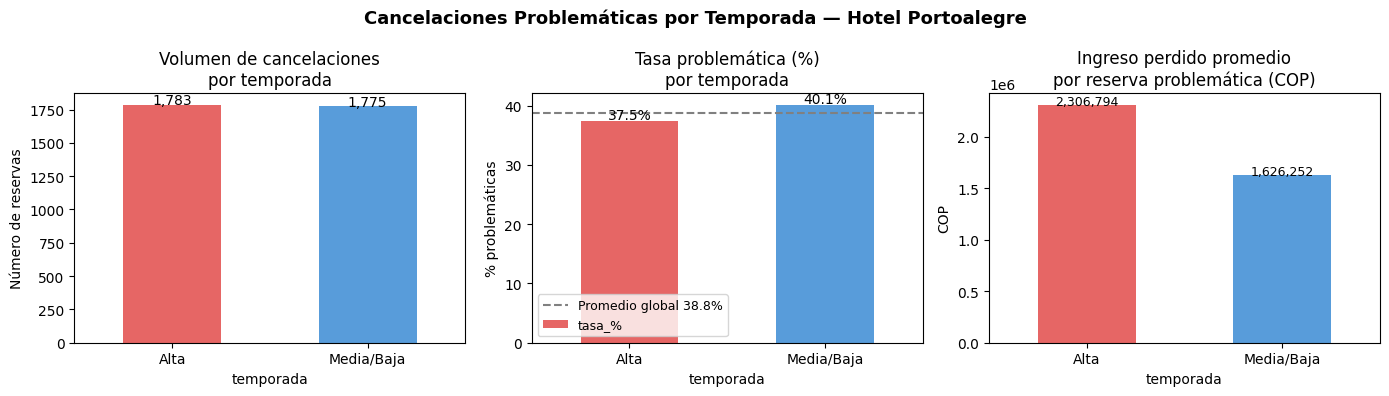

CANCELACIONES POR TEMPORADA:


,total,problematicas,tasa_%,cop_perdido_promedio
temporada,,,,
Alta,1783,669,37.5,2306794.0
Media/Baja,1775,712,40.1,1626252.0



Temporada Alta    : 37.5% de cancelaciones son problemáticas
Temporada Med/Baj : 40.1% de cancelaciones son problemáticas
-> Mayor tasa en alta: reservas especulativas sin compromiso real
-> Mayor COP en alta: habitación reasignable a tarifa premium


In [ ]:
# ── Variable de temporada ─────────────────────────────────────────────────────
MESES_ALTA = [6, 7, 8, 12, 1]

df['temporada']         = df['mes_entrada'].apply(
    lambda m: 'Alta' if m in MESES_ALTA else 'Media/Baja'
)
df['es_temporada_alta'] = (df['temporada'] == 'Alta').astype(int)

# Añadir a df_model para que entre como feature
df['es_temporada_alta'] = df['es_temporada_alta'].values

# Rename 'Total de la reserva' to 'total_cop' if it exists and hasn't been renamed yet
if 'Total de la reserva' in df.columns:
    df = df.rename(columns={'Total de la reserva': 'total_cop'})

# Ensure 'total_cop' column is numeric, cleaning if necessary
if 'total_cop' in df.columns and df['total_cop'].dtype == 'object':
    df['total_cop'] = df['total_cop'].astype(str).str.replace('COP ', '', regex=False).str.replace(',', '', regex=False).astype(float)


# ── Análisis de cancelación problemática por temporada ────────────────────────
temp_stats = df.groupby('temporada').agg(
    total             = ('target','count'),
    problematicas     = ('target','sum'),
    tasa_problematica = ('target','mean'),
    total_cop_perdido = ('total_cop','sum')
).round(3)
temp_stats['tasa_%']             = (temp_stats['tasa_problematica'] * 100).round(1)
temp_stats['cop_perdido_promedio']= (
    temp_stats['total_cop_perdido'] / temp_stats['problematicas']
).round(0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colores_t = ['#E24B4A', '#3B8BD4']

# Volumen
temp_stats['total'].plot(kind='bar', ax=axes[0], color=colores_t, alpha=0.85, rot=0)
axes[0].set_title('Volumen de cancelaciones\npor temporada')
axes[0].set_ylabel('Número de reservas')
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10)

# Tasa problemática
temp_stats['tasa_%'].plot(kind='bar', ax=axes[1], color=colores_t, alpha=0.85, rot=0)
axes[1].axhline(df['target'].mean()*100, color='gray', linestyle='--', lw=1.5,
                label=f'Promedio global {df["target"].mean()*100:.1f}%')
axes[1].set_title('Tasa problemática (%)\npor temporada')
axes[1].set_ylabel('% problemáticas')
axes[1].legend(fontsize=9)
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

# COP perdido promedio
temp_stats['cop_perdido_promedio'].plot(kind='bar', ax=axes[2], color=colores_t, alpha=0.85, rot=0)
axes[2].set_title('Ingreso perdido promedio\npor reserva problemática (COP)')
axes[2].set_ylabel('COP')
for bar in axes[2].patches:
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
                 f'{bar.get_height():,.0f}', ha='center', fontsize=9)

plt.suptitle('Cancelaciones Problemáticas por Temporada — Hotel Portoalegre',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('CANCELACIONES POR TEMPORADA:')
display(temp_stats[['total','problematicas','tasa_%','cop_perdido_promedio']])
alta_t = temp_stats.loc['Alta','tasa_%'] if 'Alta' in temp_stats.index else 0
baja_t = temp_stats.loc['Media/Baja','tasa_%'] if 'Media/Baja' in temp_stats.index else 0
print(f'\nTemporada Alta    : {alta_t:.1f}% de cancelaciones son problemáticas')
print(f'Temporada Med/Baj : {baja_t:.1f}% de cancelaciones son problemáticas')
print('-> Mayor tasa en alta: reservas especulativas sin compromiso real')
print('-> Mayor COP en alta: habitación reasignable a tarifa premium')

### Distribución de Variables

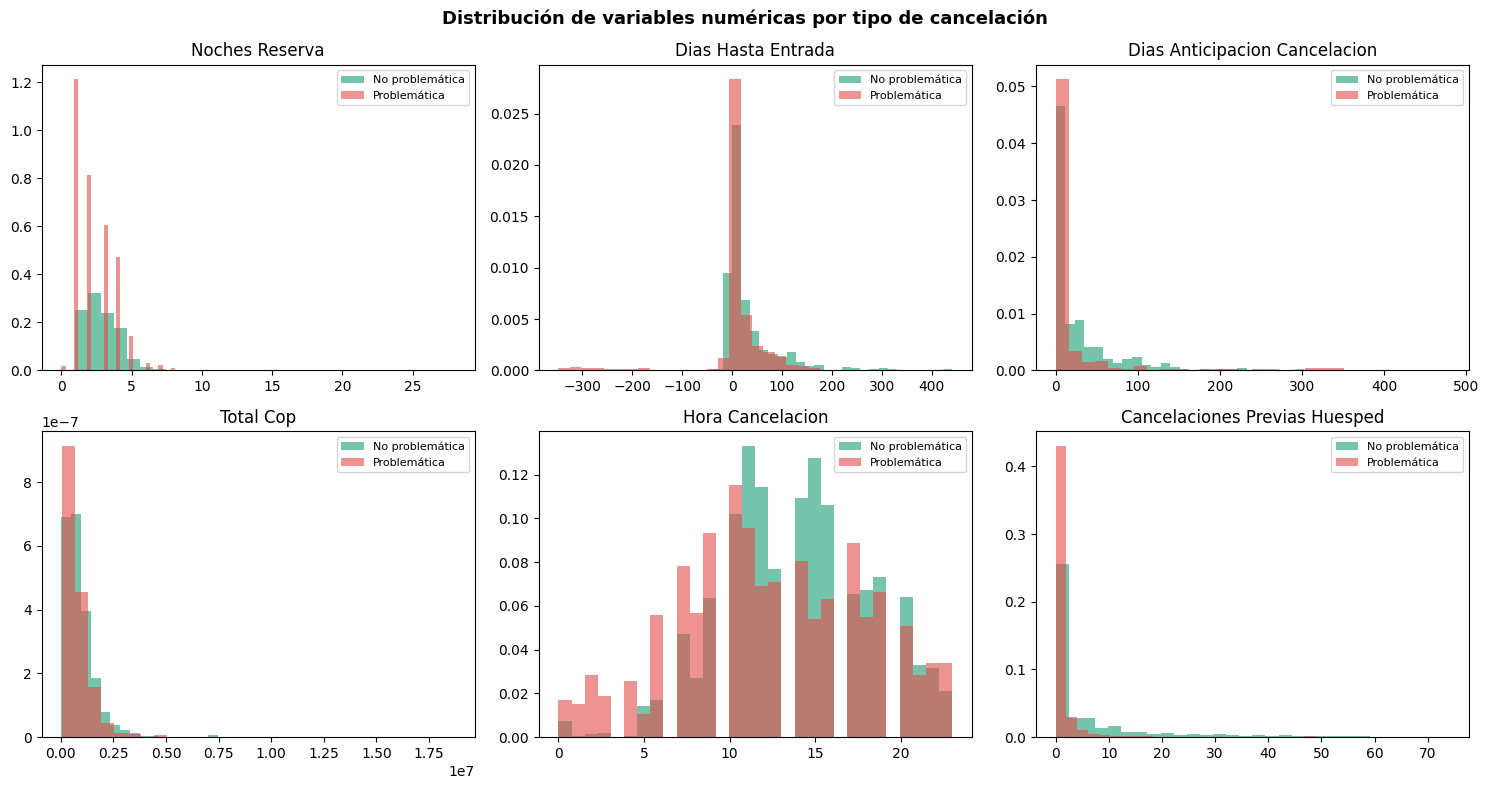

In [ ]:
num_feats = ['noches_reserva', 'dias_hasta_entrada',
             'dias_anticipacion_cancelacion', 'total_cop',
             'hora_cancelacion', 'cancelaciones_previas_huesped']

# The cleaning and conversion of 'Total de la reserva' to 'total_cop' has already been handled
# in a previous cell (6IYkXSpy4tQE) and is now correctly named 'total_cop' and numeric.
# Therefore, the following block is redundant and has been removed.

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_feats):
    data0 = df[df['target'] == 0][col].dropna()
    data1 = df[df['target'] == 1][col].dropna()
    axes[i].hist(data0, bins=30, alpha=0.6, color='#1D9E75', label='No problemática', density=True)
    axes[i].hist(data1, bins=30, alpha=0.6, color='#E24B4A', label='Problemática', density=True)
    axes[i].set_title(col.replace('_',' ').title())
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de variables numéricas por tipo de cancelación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

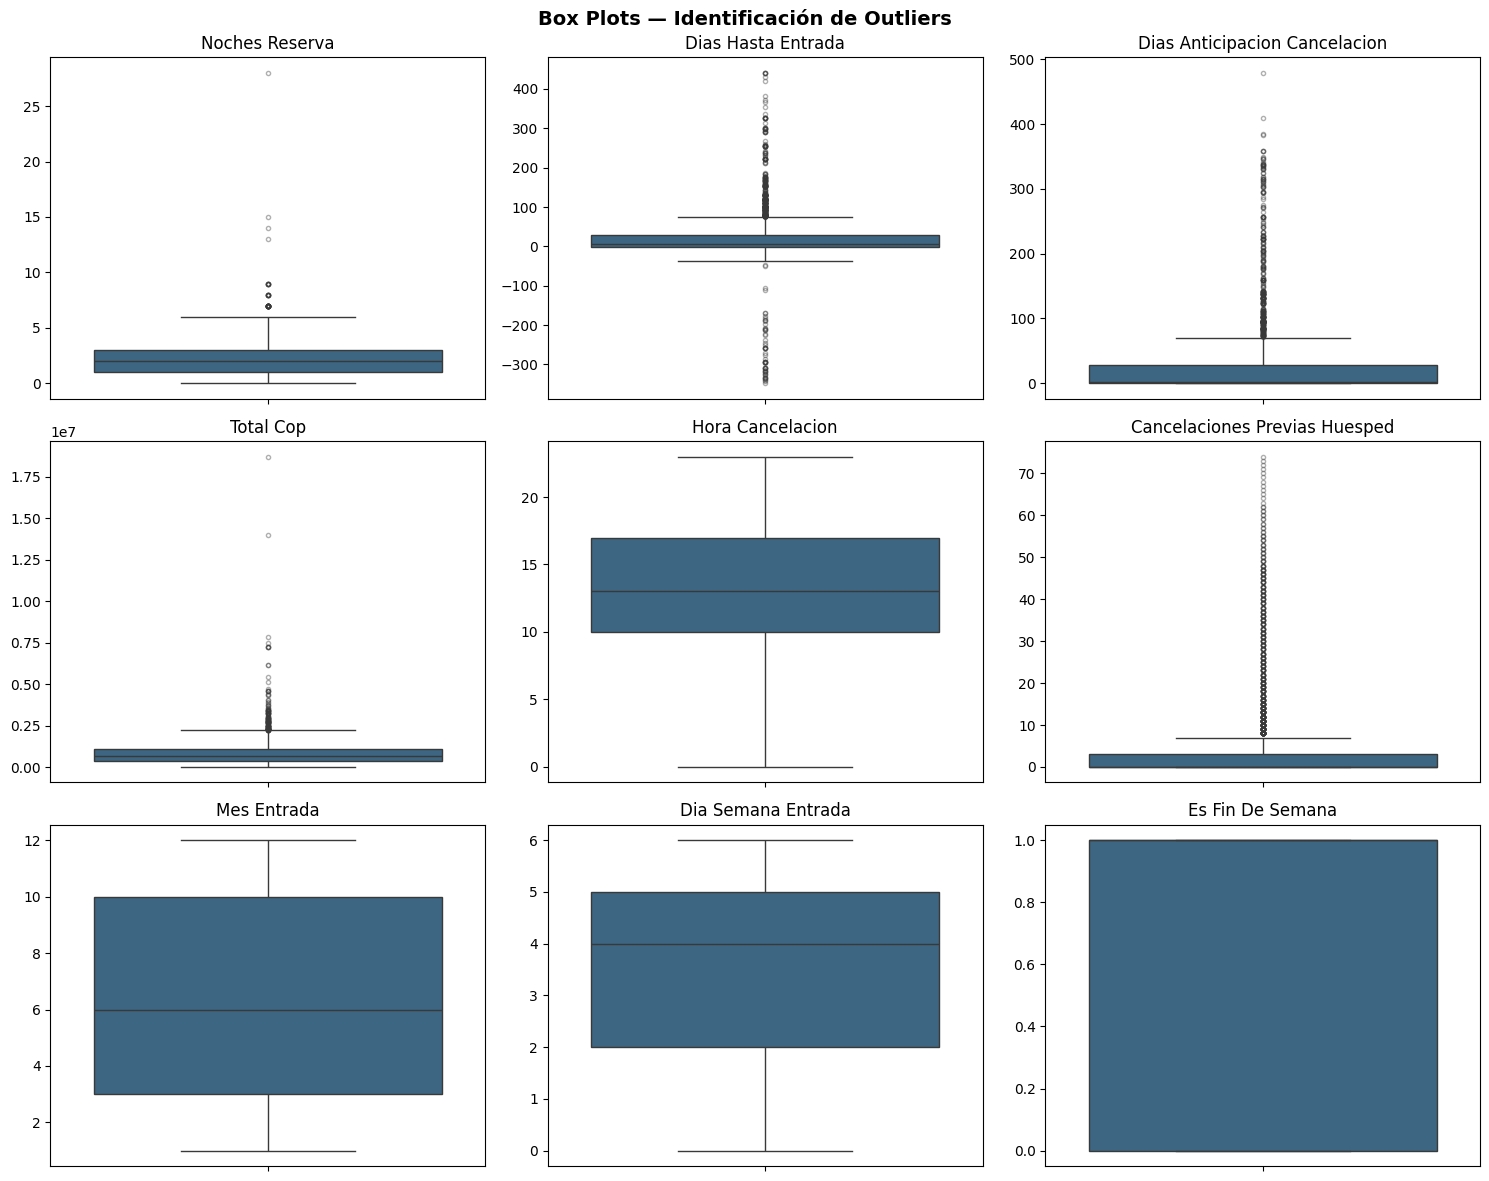

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
all_num = num_feats + ['mes_entrada', 'dia_semana_entrada', 'es_fin_de_semana']

for i, col in enumerate(all_num):
    if col in df.columns:
        sns.boxplot(y=df[col], ax=axes[i], color=PALETTE[1], flierprops={'marker':'o','markersize':3,'alpha':0.4})
        axes[i].set_title(col.replace('_',' ').title())
        axes[i].set_ylabel('')

for j in range(len(all_num), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Box Plots — Identificación de Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Matriz de Correlación

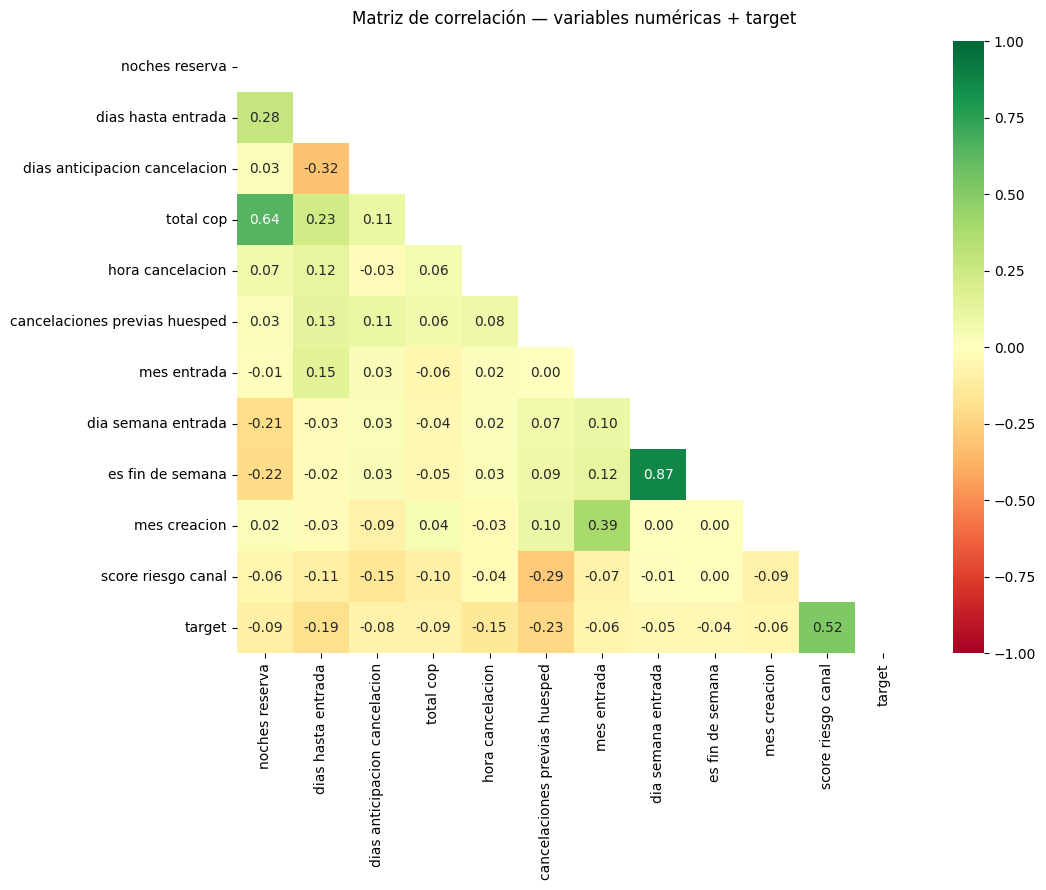

Correlaciones con el target (cancelación problemática):
score_riesgo_canal               0.523
cancelaciones_previas_huesped   -0.228
dias_hasta_entrada              -0.192
hora_cancelacion                -0.147
noches_reserva                  -0.094
total_cop                       -0.086
dias_anticipacion_cancelacion   -0.079
mes_entrada                     -0.064
mes_creacion                    -0.059
dia_semana_entrada              -0.045
es_fin_de_semana                -0.044

CONCLUSIONES PARA EL MODELO:
• dias_hasta_entrada y dias_anticipacion_cancelacion: predictores temporales más fuertes
• score_riesgo_canal: predictor de dominio con contribución directa
• cancelaciones_previas_huesped: captura patrón especulativo del titular
• Variables de estacionalidad (mes, fin_de_semana): valor predictivo en interacción con Canal


In [ ]:
num_all = num_feats + ['mes_entrada','dia_semana_entrada','es_fin_de_semana',
                       'mes_creacion','score_riesgo_canal','target']
num_all = [c for c in num_all if c in df.columns]
corr = df[num_all].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=[c.replace('_',' ') for c in corr.columns],
            yticklabels=[c.replace('_',' ') for c in corr.index])
ax.set_title('Matriz de correlación — variables numéricas + target', pad=12)
plt.tight_layout()
plt.show()

# Correlaciones con el target
corr_target = corr['target'].drop('target').sort_values(key=abs, ascending=False)
print('Correlaciones con el target (cancelación problemática):')
print(corr_target.round(3).to_string())
print()
print('CONCLUSIONES PARA EL MODELO:')
print('• dias_hasta_entrada y dias_anticipacion_cancelacion: predictores temporales más fuertes')
print('• score_riesgo_canal: predictor de dominio con contribución directa')
print('• cancelaciones_previas_huesped: captura patrón especulativo del titular')
print('• Variables de estacionalidad (mes, fin_de_semana): valor predictivo en interacción con Canal')

## Preparación del Dataset para Modelado

> **Corrección crítica — Data Leakage:**
> Las features `cancelaciones_previas_huesped` y `score_riesgo_canal` usan el target
> para calcularse. Si se construyen sobre el dataset completo antes del split, los datos
> de test contaminan el entrenamiento. **Se calculan exclusivamente desde train post-split.**
>
> Igualmente, se reemplaza `train_test_split` aleatorio por **split temporal** (ordenado
> por `Fecha creación`), ya que el modelo en producción siempre predice el futuro.

In [ ]:
import pandas as pd

# ── Tabla formal de variables — Dataset para modelado ─────────────────────────
FEATURES_NUM = [
    'noches_reserva', 'dias_hasta_entrada', 'dias_anticipacion_cancelacion',
    'mes_entrada', 'dia_semana_entrada', 'es_fin_de_semana',
    'hora_cancelacion', 'total_cop', 'es_temporada_alta'
    # NOTA: cancelaciones_previas_huesped y score_riesgo_canal → post-split
]
FEATURES_CAT = ['Canal', 'Cancelada por', 'Habitación']
TARGET = 'target'

tabla_vars = pd.DataFrame([
    # ── Numéricas ──────────────────────────────────────────────────────────
    {'#': 0,  'Variable': 'noches_reserva',               'Tipo': 'Numérica',            'Tratamiento': 'Sin cambio',
     'Justificación': 'Estadías largas tienen menor tasa de cancelación problemática'},
    {'#': 1,  'Variable': 'dias_hasta_entrada',            'Tipo': 'Numérica',            'Tratamiento': 'Derivada de fecha',
     'Justificación': 'Cancelaciones cercanas al check-in son más frecuentemente problemáticas'},
    {'#': 2,  'Variable': 'dias_anticipacion_cancelacion', 'Tipo': 'Numérica',            'Tratamiento': 'Derivada de fecha',
     'Justificación': 'Cancelaciones muy rápidas post-reserva señalan No Show o pago rechazado'},
    {'#': 3,  'Variable': 'mes_entrada',                   'Tipo': 'Numérica',            'Tratamiento': 'Derivada de fecha',
     'Justificación': 'La estacionalidad afecta la demanda y el comportamiento de cancelación'},
    {'#': 4,  'Variable': 'dia_semana_entrada',             'Tipo': 'Numérica',            'Tratamiento': 'Derivada de fecha',
     'Justificación': 'Patrones de cancelación difieren entre semana y fin de semana'},
    {'#': 5,  'Variable': 'es_fin_de_semana',               'Tipo': 'Numérica',            'Tratamiento': 'Derivada de fecha',
     'Justificación': 'Reservas de fin de semana tienen perfil de riesgo distinto al entre semana'},
    {'#': 6,  'Variable': 'hora_cancelacion',               'Tipo': 'Numérica',            'Tratamiento': 'Derivada de fecha',
     'Justificación': 'Cancelaciones automáticas (pago rechazado) ocurren a horas específicas del sistema'},
    {'#': 7,  'Variable': 'total_cop',                      'Tipo': 'Numérica',            'Tratamiento': 'Limpieza texto → float / imputación mediana',
     'Justificación': 'Reservas de mayor valor tienen mayor impacto financiero al ser problemáticas'},
    {'#': 8,  'Variable': 'es_temporada_alta',              'Tipo': 'Numérica (binaria)',  'Tratamiento': 'Derivada de fecha (binaria)',
     'Justificación': 'Alta temporada determina el costo de oportunidad de cada cancelación'},
    # ── Engineered post-split ──────────────────────────────────────────────
    {'#': 9,  'Variable': 'cancelaciones_previas_huesped',  'Tipo': 'Numérica',            'Tratamiento': 'Nueva — historial huésped (post-split, cumcount)',
     'Justificación': 'Historial acumulado anticausal del huésped; calculada solo desde train para evitar leakage'},
    {'#': 10, 'Variable': 'score_riesgo_canal',              'Tipo': 'Numérica',            'Tratamiento': 'Nueva — score dominio hotelero (post-split)',
     'Justificación': 'Nivel de riesgo 1-3 por canal calculado desde train; Booking Engine=89.7% problemático'},
    # ── Categóricas ────────────────────────────────────────────────────────
    {'#': 11, 'Variable': 'Canal',                           'Tipo': 'Categórica (original)', 'Tratamiento': "Imputación 'Desconocido' + One-Hot Encoding",
     'Justificación': 'Canal de reserva determina las políticas de pago y el perfil del cliente'},
    {'#': 12, 'Variable': 'Cancelada por',                   'Tipo': 'Categórica (original)', 'Tratamiento': 'One-Hot Encoding',
     'Justificación': 'El agente/sistema que cancela es predictor clave (Booking Engine=cancelación automática)'},
    {'#': 13, 'Variable': 'Habitación',                      'Tipo': 'Categórica (original)', 'Tratamiento': "Imputación 'Desconocido' + One-Hot Encoding",
     'Justificación': 'Tipo de habitación refleja segmento de cliente y nivel de precio'},
])

tabla_excl = pd.DataFrame([
    {'Variable': 'ID de la reserva',  'Razón exclusión': 'Identificador — sin valor predictivo generalizable'},
    {'Variable': 'huésped (nombre)',   'Razón exclusión': 'PII — excluir; su patrón se captura en cancelaciones_previas_huesped'},
    {'Variable': 'Descripción',        'Razón exclusión': '63.7% nulos estructurales (cancelaciones automáticas sin texto)'},
    {'Variable': 'Documento',          'Razón exclusión': 'PII — no aporta valor predictivo'},
    {'Variable': 'Motivo',             'Razón exclusión': 'Fuente del target — excluir para evitar data leakage'},
    {'Variable': 'Tipo doc',           'Razón exclusión': 'Sin valor predictivo generalizable (36.8% nulos)'},
    {'Variable': 'Creada por',         'Razón exclusión': 'Específico del operador; baja generalización fuera del contexto del hotel'},
    {'Variable': 'Fecha creación',     'Razón exclusión': 'Usada solo para split temporal — no ingresa como feature al modelo'},
])

print('=' * 70)
print('DATASET FINAL PARA MODELADO — DESCRIPCIÓN FORMAL (CRISP-DM)')
print('=' * 70)
print(f'  Registros totales            : {len(df):,}')
print(f'  Variables predictoras        : {len(tabla_vars)} originales → expandidas por OHE')
print(f'    - Numéricas (original)     : {len([v for v in tabla_vars["Tipo"] if "Categórica" not in v])}')
print(f'    - Categóricas (encoded)    : {len(FEATURES_CAT)} → OHE')
print(f'  Variable objetivo (target)   : {TARGET} (binaria 0/1)')
print(f'  Balance del target           : {df[TARGET].mean()*100:.1f}% problemática / {(1-df[TARGET].mean())*100:.1f}% no problemática')
print(f'  Nulos restantes              : 0')
print()
print('VARIABLES EXCLUIDAS Y RAZÓN:')
for _, row in tabla_excl.iterrows():
    print(f'  - {row["Variable"]:<22}: {row["Razón exclusión"]}')

print()
print('VARIABLES QUE INGRESAN AL MODELO:')
display(tabla_vars[['#', 'Variable', 'Tipo', 'Tratamiento', 'Justificación']])

print()
print('RECOMENDACIONES PARA MODELADO:')
print('  1. Algoritmos preferidos: Random Forest, XGBoost, LightGBM (capturan interacciones no lineales)')
print('  2. Métricas objetivo    : F1-score ponderado, AUC-ROC, Recall ≥ 0.70')
print('  3. Desbalance moderado  : SMOTE dentro del pipeline (no class_weight + SMOTE simultáneamente)')
print('  4. Validación           : split temporal 70/30 por Fecha creación')
print('  5. Acción independiente : investigar pasarela de cobro del Booking Engine (>89% cancelaciones problemáticas)')

# Guardar para uso posterior
df_model = df[FEATURES_NUM + FEATURES_CAT + [TARGET, 'Fecha creación', 'huésped', 'Canal', 'Fecha cancelación']].copy()
median_cop = df_model['total_cop'].median()
df_model['total_cop'] = df_model['total_cop'].fillna(median_cop)
for col in ['Canal', 'Habitación']:
    df_model[col] = df_model[col].fillna('Desconocido')
print(f'\nNulos restantes en df_model: {df_model.isnull().sum().sum()}')
print(f'Shape df_model: {df_model.shape}')


DATASET FINAL PARA MODELADO — DESCRIPCIÓN FORMAL (CRISP-DM)
  Registros totales            : 3,558
  Variables predictoras        : 14 originales → expandidas por OHE
    - Numéricas (original)     : 11
    - Categóricas (encoded)    : 3 → OHE
  Variable objetivo (target)   : target (binaria 0/1)
  Balance del target           : 38.8% problemática / 61.2% no problemática
  Nulos restantes              : 0

VARIABLES EXCLUIDAS Y RAZÓN:
  - ID de la reserva      : Identificador — sin valor predictivo generalizable
  - huésped (nombre)      : PII — excluir; su patrón se captura en cancelaciones_previas_huesped
  - Descripción           : 63.7% nulos estructurales (cancelaciones automáticas sin texto)
  - Documento             : PII — no aporta valor predictivo
  - Motivo                : Fuente del target — excluir para evitar data leakage
  - Tipo doc              : Sin valor predictivo generalizable (36.8% nulos)
  - Creada por            : Específico del operador; baja generalización f

,#,Variable,Tipo,Tratamiento,Justificación
0,0,noches_reserva,Numérica,Sin cambio,Estadías largas tienen menor tasa de cancelaci...
1,1,dias_hasta_entrada,Numérica,Derivada de fecha,Cancelaciones cercanas al check-in son más fre...
2,2,dias_anticipacion_cancelacion,Numérica,Derivada de fecha,Cancelaciones muy rápidas post-reserva señalan...
3,3,mes_entrada,Numérica,Derivada de fecha,La estacionalidad afecta la demanda y el compo...
4,4,dia_semana_entrada,Numérica,Derivada de fecha,Patrones de cancelación difieren entre semana ...
5,5,es_fin_de_semana,Numérica,Derivada de fecha,Reservas de fin de semana tienen perfil de rie...
6,6,hora_cancelacion,Numérica,Derivada de fecha,Cancelaciones automáticas (pago rechazado) ocu...
7,7,total_cop,Numérica,Limpieza texto → float / imputación mediana,Reservas de mayor valor tienen mayor impacto f...
8,8,es_temporada_alta,Numérica (binaria),Derivada de fecha (binaria),Alta temporada determina el costo de oportunid...
9,9,cancelaciones_previas_huesped,Numérica,"Nueva — historial huésped (post-split, cumcount)",Historial acumulado anticausal del huésped; ca...



RECOMENDACIONES PARA MODELADO:
  1. Algoritmos preferidos: Random Forest, XGBoost, LightGBM (capturan interacciones no lineales)
  2. Métricas objetivo    : F1-score ponderado, AUC-ROC, Recall ≥ 0.70
  3. Desbalance moderado  : SMOTE dentro del pipeline (no class_weight + SMOTE simultáneamente)
  4. Validación           : split temporal 70/30 por Fecha creación
  5. Acción independiente : investigar pasarela de cobro del Booking Engine (>89% cancelaciones problemáticas)

Nulos restantes en df_model: 0
Shape df_model: (3558, 17)


## Split Temporal 70% Train — 30% Test

> Se ordena por `Fecha creación` y se corta cronológicamente para replicar el
> escenario de producción: el modelo aprende del pasado y se evalúa sobre el futuro.

In [ ]:
# ── Split temporal ───────────────────────────────────────────────────────────
df_sorted = df_model.sort_values('Fecha creación').reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.70)
train_df  = df_sorted.iloc[:split_idx].copy()
test_df   = df_sorted.iloc[split_idx:].copy()

print(f'Train : {len(train_df):,} registros (70%)')
print(f'Test  : {len(test_df):,}  registros (30%)')
print(f'Fecha corte: {test_df["Fecha creación"].min().date()}')
print(f'  Train — target=1: {train_df[TARGET].mean()*100:.1f}%')
print(f'  Test  — target=1: {test_df[TARGET].mean()*100:.1f}%')


Train : 2,490 registros (70%)
Test  : 1,068  registros (30%)
Fecha corte: 2024-12-21
  Train — target=1: 36.6%
  Test  — target=1: 43.9%


## Features Grupales — Calculadas Solo desde Train (Anti-Leakage)

In [ ]:
import pandas as pd

# Eliminar columnas duplicadas
train_df = train_df.loc[:, ~train_df.columns.duplicated(keep='first')]
test_df  = test_df.loc[:,  ~test_df.columns.duplicated(keep='first')]

# ── cancelaciones_previas_huesped: cumcount anticausal ────────────────────────
train_df = train_df.sort_values('Fecha creación')
train_df['cancelaciones_previas_huesped'] = (
    train_df.groupby('huésped').cumcount()
)
conteo_train = train_df.groupby('huésped')['cancelaciones_previas_huesped'].max()
test_df['cancelaciones_previas_huesped'] = (
    test_df['huésped'].map(conteo_train).fillna(0)
)

# ── score_riesgo_canal: tasa problemática por canal, solo desde train ─────────
canal_riesgo_train = train_df.groupby('Canal')[TARGET].mean()
q33 = canal_riesgo_train.quantile(0.33)
q66 = canal_riesgo_train.quantile(0.66)

def asignar_score(tasa):
    if tasa >= q66: return 3
    elif tasa >= q33: return 2
    else: return 1

canal_score_map = {c: asignar_score(t) for c, t in canal_riesgo_train.items()}
canal_score_map['Desconocido'] = 2

for df_ in [train_df, test_df]:
    df_['score_riesgo_canal'] = df_['Canal'].map(canal_score_map).fillna(2)

print('score_riesgo_canal calculado desde train:')
score_df = pd.DataFrame({
    'Canal': canal_riesgo_train.index,
    'Tasa_%': (canal_riesgo_train * 100).round(1),
    'Score': [canal_score_map[c] for c in canal_riesgo_train.index]
})
display(score_df)


score_riesgo_canal calculado desde train:


,Canal,Tasa_%,Score
Canal,,,
Booking Engine,Booking Engine,89.7,3
Booking.com,Booking.com,24.0,2
Convenio con empresa,Convenio con empresa,17.6,1
Convenio con persona natural,Convenio con persona natural,0.0,1
Desconocido,Desconocido,15.8,2
Expedia,Expedia,0.0,1
Hotel Portoalegre,Hotel Portoalegre,20.0,2
Noche Propietarios,Noche Propietarios,23.1,2
Price Travel,Price Travel,71.4,3


In [ ]:
# ── One-Hot Encoding y construcción X_train / X_test ─────────────────────────
FEATURES_FINAL = FEATURES_NUM + ['cancelaciones_previas_huesped', 'score_riesgo_canal'] + FEATURES_CAT

train_enc = pd.get_dummies(train_df[FEATURES_FINAL + [TARGET]], columns=FEATURES_CAT, drop_first=True)
test_enc  = pd.get_dummies(test_df[FEATURES_FINAL  + [TARGET]], columns=FEATURES_CAT, drop_first=True)

X_train = train_enc.drop(columns=[TARGET])
y_train = train_enc[TARGET]
X_test  = test_enc.drop(columns=[TARGET])
y_test  = test_enc[TARGET]

# Alinear columnas — test puede tener categorías no vistas en train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  | y_test  : {y_test.shape}')
print(f'Nulos en X_train: {X_train.isnull().sum().sum()}')
print(f'Nulos en X_test : {X_test.isnull().sum().sum()}')
print(f'Balance train  target=1: {y_train.mean()*100:.1f}%')
print(f'Balance test   target=1: {y_test.mean()*100:.1f}%')


X_train: (2490, 88) | y_train: (2490,)
X_test : (1068, 88)  | y_test  : (1068,)
Nulos en X_train: 0
Nulos en X_test : 0
Balance train  target=1: 36.6%
Balance test   target=1: 43.9%


## Modelo Random Forest — Entrenamiento Base

> Se usa **SMOTE dentro del pipeline** (ImbPipeline de imbalanced-learn) para balancear
> las clases únicamente en el conjunto de entrenamiento, sin contaminar el test.
> Se reemplaza `class_weight='balanced'` + SMOTE (doble balanceo) por SMOTE solo.

=== MODELO BASE — MÉTRICAS EN TEST ===
Accuracy : 0.8811
AUC-ROC  : 0.9181
Recall   : 0.7889
F1 pond. : 0.8795

              precision    recall  f1-score   support

    No prob.       0.85      0.95      0.90       599
Problemática       0.93      0.79      0.85       469

    accuracy                           0.88      1068
   macro avg       0.89      0.87      0.88      1068
weighted avg       0.89      0.88      0.88      1068



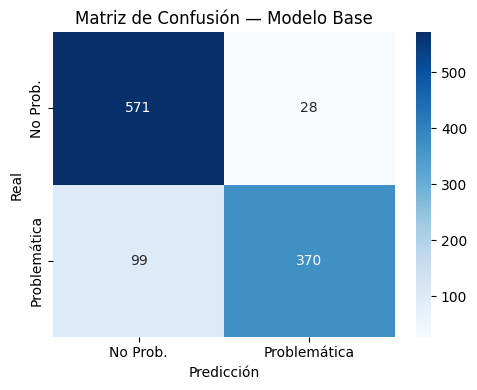

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

# Pipeline: SMOTE → RF (sin class_weight para evitar doble balanceo)
pipe_base = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

pipe_base.fit(X_train, y_train)
y_pred_base  = pipe_base.predict(X_test)
y_proba_base = pipe_base.predict_proba(X_test)[:, 1]

print('=== MODELO BASE — MÉTRICAS EN TEST ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_base):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_proba_base):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_base):.4f}')
print(f'F1 pond. : {f1_score(y_test, y_pred_base, average="weighted"):.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=['No prob.', 'Problemática']))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_base), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Prob.', 'Problemática'],
            yticklabels=['No Prob.', 'Problemática'], ax=ax)
ax.set_title('Matriz de Confusión — Modelo Base')
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.tight_layout(); plt.show()


## Optimización de Hiperparámetros — GridSearchCV con StratifiedKFold

> Grid reducido y curado: 8 combinaciones × 5 folds = 40 fits.
> Se optimiza `f1_weighted` como métrica objetivo dado el desbalance de clases.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# ── Grid con regularización más agresiva para reducir GAP ────────────────────
param_grid_rf = {
    'clf__n_estimators'     : [300, 500],
    'clf__max_depth'        : [5, 6],         # bajado de 10 → menos profundidad
    'clf__min_samples_leaf' : [20, 30, 50],   # subido de 10 → hojas más grandes
    'clf__min_samples_split': [30, 50],        # subido de 20 → splits más conservadores
    'clf__max_features'     : ['sqrt', 0.5],  # nueva — limita features por árbol
    'clf__max_samples'      : [0.7, 0.8],     # nueva — bagging 70–80% del train
}
# Total: 2×2×3×2×2×2 = 96 combos × 10 folds = 960 fits
# Se usan 10 folds para estimación más estable del GAP real

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

pipe_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   RandomForestClassifier(random_state=42, n_jobs=-1))
])

grid_search = GridSearchCV(
    estimator  = pipe_rf,
    param_grid = param_grid_rf,
    cv         = skf,
    scoring    = 'f1_weighted',
    n_jobs     = -1,
    verbose    = 1
)

print('Iniciando búsqueda RF (regularización reforzada, 10 folds)...')
grid_search.fit(X_train, y_train)

print(f'\nMejores parámetros RF : {grid_search.best_params_}')
print(f'Mejor F1 ponderado CV : {grid_search.best_score_:.4f}')
rf_best = grid_search.best_estimator_

Iniciando búsqueda RF (regularización reforzada, 10 folds)...
Fitting 10 folds for each of 96 candidates, totalling 960 fits

Mejores parámetros RF : {'clf__max_depth': 6, 'clf__max_features': 0.5, 'clf__max_samples': 0.8, 'clf__min_samples_leaf': 20, 'clf__min_samples_split': 50, 'clf__n_estimators': 500}
Mejor F1 ponderado CV : 0.9247


=== MODELO OPTIMIZADO — MÉTRICAS EN TEST ===
Accuracy : 0.8820
AUC-ROC  : 0.9170
Recall   : 0.7719
F1 pond. : 0.8800

              precision    recall  f1-score   support

    No prob.       0.84      0.97      0.90       599
Problemática       0.95      0.77      0.85       469

    accuracy                           0.88      1068
   macro avg       0.90      0.87      0.88      1068
weighted avg       0.89      0.88      0.88      1068



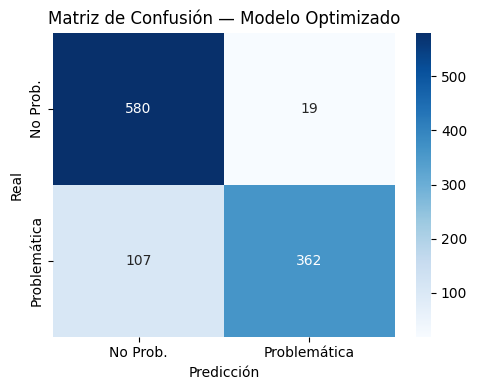

In [ ]:
# ── Evaluación modelo optimizado en test ─────────────────────────────────────
y_pred_opt  = rf_best.predict(X_test)
y_proba_opt = rf_best.predict_proba(X_test)[:, 1]

print('=== MODELO OPTIMIZADO — MÉTRICAS EN TEST ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_opt):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_proba_opt):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_opt):.4f}')
print(f'F1 pond. : {f1_score(y_test, y_pred_opt, average="weighted"):.4f}')
print()
print(classification_report(y_test, y_pred_opt, target_names=['No prob.', 'Problemática']))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Prob.', 'Problemática'],
            yticklabels=['No Prob.', 'Problemática'], ax=ax)
ax.set_title('Matriz de Confusión — Modelo Optimizado')
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.tight_layout(); plt.show()


## Diagnóstico de Overfitting — GAP Train vs Test

> Umbral de riesgo: **GAP AUC > 0.10** se considera overfitting.
> Entre 0.05 y 0.10: zona de alerta moderada. Menor a 0.05: generalización robusta.

=== GAP TRAIN vs TEST ===
Umbral overfitting (GAP AUC): 0.10


,Métrica,Train,Test,GAP (Train-Test),Diagnóstico
0,Accuracy,0.9325,0.8820,0.0505,⚠ Moderado
1,AUC-ROC,0.9821,0.9170,0.0651,⚠ Moderado
2,Recall,0.8399,0.7719,0.0681,⚠ Moderado
3,F1 pond.,0.9313,0.8800,0.0514,⚠ Moderado


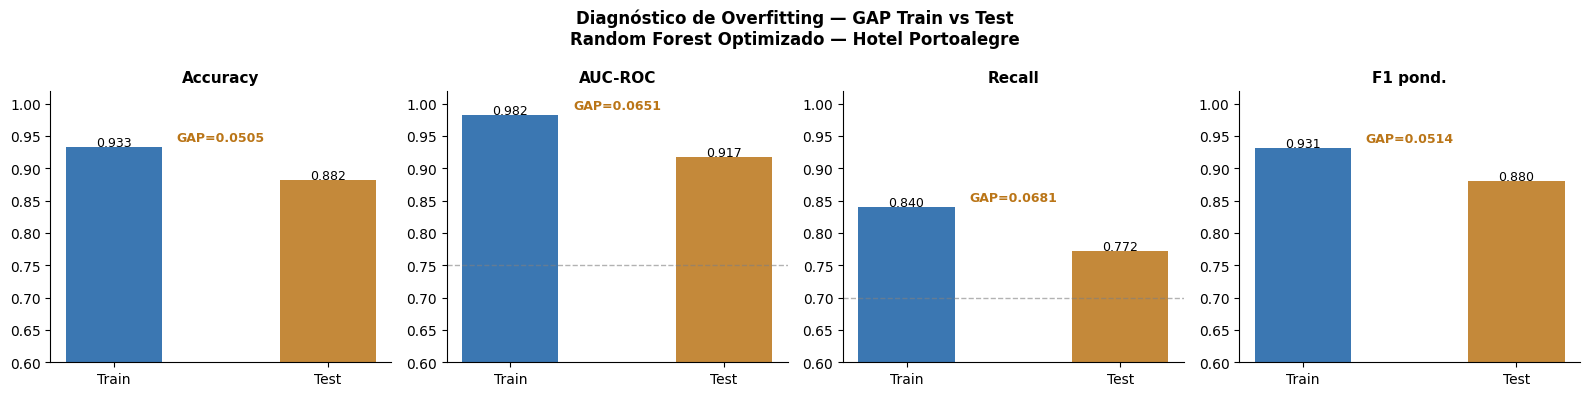

In [ ]:
from sklearn.metrics import roc_auc_score, recall_score, f1_score, accuracy_score

# Métricas en train
y_train_pred  = rf_best.predict(X_train)
y_train_proba = rf_best.predict_proba(X_train)[:, 1]

metricas = {
    'Accuracy' : (accuracy_score(y_train, y_train_pred),  accuracy_score(y_test, y_pred_opt)),
    'AUC-ROC'  : (roc_auc_score(y_train,  y_train_proba), roc_auc_score(y_test, y_proba_opt)),
    'Recall'   : (recall_score(y_train,   y_train_pred),  recall_score(y_test, y_pred_opt)),
    'F1 pond.' : (f1_score(y_train, y_train_pred, average='weighted'),
                  f1_score(y_test,  y_pred_opt,   average='weighted')),
}

import pandas as pd
df_gap = pd.DataFrame([
    {'Métrica': k, 'Train': v[0], 'Test': v[1],
     'GAP (Train-Test)': round(v[0]-v[1], 4),
     'Diagnóstico': ('✅ Robusto'   if v[0]-v[1] < 0.05  else
                     '⚠ Moderado'  if v[0]-v[1] < 0.10  else
                     '❌ Overfitting')}
    for k, v in metricas.items()
])

print('=== GAP TRAIN vs TEST ===')
print(f'Umbral overfitting (GAP AUC): 0.10')
display(df_gap.round(4))

# Gráfico comparativo train vs test
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
nombres = list(metricas.keys())
for ax, nombre in zip(axes, nombres):
    tr, te = metricas[nombre]
    gap = tr - te
    color = '#E24B4A' if gap >= 0.10 else '#BA7517' if gap >= 0.05 else '#1D9E75'
    ax.bar(['Train', 'Test'], [tr, te], color=['#185FA5', color], alpha=0.85, width=0.45)
    ax.set_ylim(0.60, 1.02)
    ax.set_title(nombre, fontsize=11, fontweight='bold')
    ax.text(0.5, max(tr, te) + 0.01, f'GAP={gap:.4f}', ha='center',
            fontsize=9, color=color, fontweight='bold')
    ax.axhline(0.75 if nombre == 'AUC-ROC' else 0.70 if nombre == 'Recall' else 0,
               color='gray', linestyle='--', lw=1, alpha=0.6)
    ax.spines[['top','right']].set_visible(False)
    for i, v in enumerate([tr, te]):
        ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Diagnóstico de Overfitting — GAP Train vs Test\nRandom Forest Optimizado — Hotel Portoalegre',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Curvas de Aprendizaje — Diagnóstico de Generalización

> Las curvas de aprendizaje muestran cómo evoluciona el rendimiento del modelo
> a medida que aumenta el tamaño del conjunto de entrenamiento.
>
> - **Curvas que convergen**: el modelo generaliza bien.
> - **Gap grande y estable**: overfitting → ajustar regularización.
> - **Ambas curvas bajas**: underfitting → más datos o features.

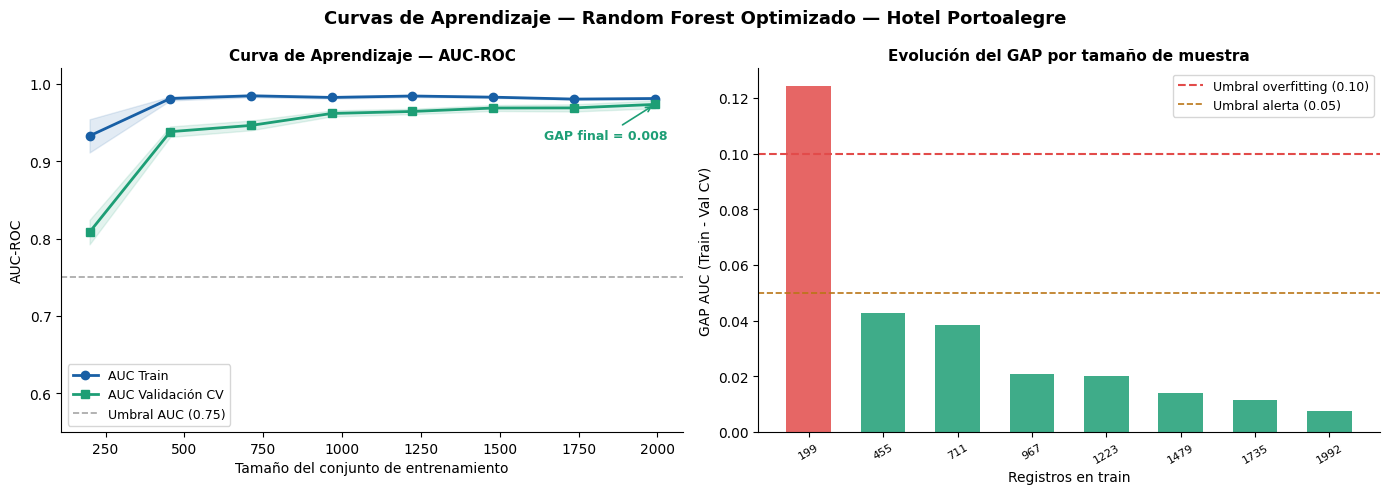


GAP AUC en conjunto completo de train: 0.0076
Diagnóstico: ✅ Robusto


In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

# Extraer el clasificador del pipeline para la curva de aprendizaje
rf_clf = grid_search.best_estimator_.named_steps['clf']

# Curva de aprendizaje sobre X_train / y_train (sin SMOTE para medir datos reales)
train_sizes, train_scores, val_scores = learning_curve(
    rf_clf, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Curva de aprendizaje AUC
ax = axes[0]
ax.plot(train_sizes, train_mean, 'o-', color='#185FA5', label='AUC Train', linewidth=2)
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.12, color='#185FA5')
ax.plot(train_sizes, val_mean, 's-', color='#1D9E75', label='AUC Validación CV', linewidth=2)
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.12, color='#1D9E75')
ax.axhline(0.75, color='gray', linestyle='--', lw=1.2, alpha=0.7, label='Umbral AUC (0.75)')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('AUC-ROC')
ax.set_title('Curva de Aprendizaje — AUC-ROC', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0.55, 1.02)
ax.spines[['top','right']].set_visible(False)

# Anotar GAP final
gap_final = train_mean[-1] - val_mean[-1]
color_gap = '#E24B4A' if gap_final >= 0.10 else '#BA7517' if gap_final >= 0.05 else '#1D9E75'
ax.annotate(f'GAP final = {gap_final:.3f}',
            xy=(train_sizes[-1], val_mean[-1]),
            xytext=(-80, -25), textcoords='offset points',
            fontsize=9, color=color_gap, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=color_gap, lw=1.2))

# Panel 2: GAP por tamaño de muestra
ax2 = axes[1]
gaps = train_mean - val_mean
bar_colors = ['#E24B4A' if g >= 0.10 else '#BA7517' if g >= 0.05 else '#1D9E75' for g in gaps]
ax2.bar(range(len(gaps)), gaps, color=bar_colors, alpha=0.85, width=0.6)
ax2.axhline(0.10, color='#E24B4A', linestyle='--', lw=1.5, label='Umbral overfitting (0.10)')
ax2.axhline(0.05, color='#BA7517', linestyle='--', lw=1.2, label='Umbral alerta (0.05)')
ax2.set_xticks(range(len(train_sizes)))
ax2.set_xticklabels([f'{int(s)}' for s in train_sizes], rotation=30, fontsize=8)
ax2.set_xlabel('Registros en train')
ax2.set_ylabel('GAP AUC (Train - Val CV)')
ax2.set_title('Evolución del GAP por tamaño de muestra', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('Curvas de Aprendizaje — Random Forest Optimizado — Hotel Portoalegre',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nGAP AUC en conjunto completo de train: {gap_final:.4f}')
print('Diagnóstico:', '✅ Robusto' if gap_final < 0.05 else '⚠ Moderado' if gap_final < 0.10 else '❌ Overfitting')


## Curva ROC y Umbral Óptimo (Estadístico de Youden)

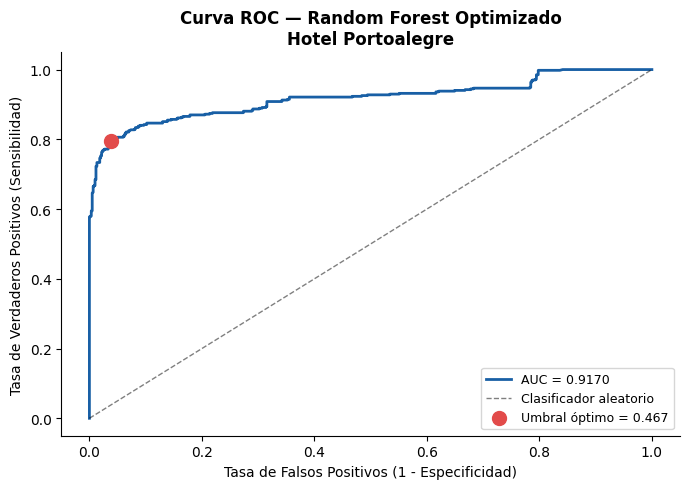

Umbral óptimo (Youden J): 0.4667
TPR en umbral óptimo    : 0.7953
FPR en umbral óptimo    : 0.0384


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

fpr, tpr, thresholds = roc_curve(y_test, y_proba_opt)
auc_val = roc_auc_score(y_test, y_proba_opt)

# Umbral óptimo: Youden J = TPR - FPR (máxima distancia a la diagonal)
youden_j = tpr - fpr
opt_idx  = np.argmax(youden_j)
opt_umbral = thresholds[opt_idx]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#185FA5', lw=2, label=f'AUC = {auc_val:.4f}')
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Clasificador aleatorio')
ax.scatter(fpr[opt_idx], tpr[opt_idx], color='#E24B4A', s=100, zorder=5,
           label=f'Umbral óptimo = {opt_umbral:.3f}')
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax.set_title('Curva ROC — Random Forest Optimizado\nHotel Portoalegre', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Umbral óptimo (Youden J): {opt_umbral:.4f}')
print(f'TPR en umbral óptimo    : {tpr[opt_idx]:.4f}')
print(f'FPR en umbral óptimo    : {fpr[opt_idx]:.4f}')


## Importancia de Variables — Gini + Permutation Importance en Test

> Se reportan ambas métricas. La **Permutation Importance evaluada en test** es más
> confiable porque mide el impacto real sobre datos no vistos por el modelo.

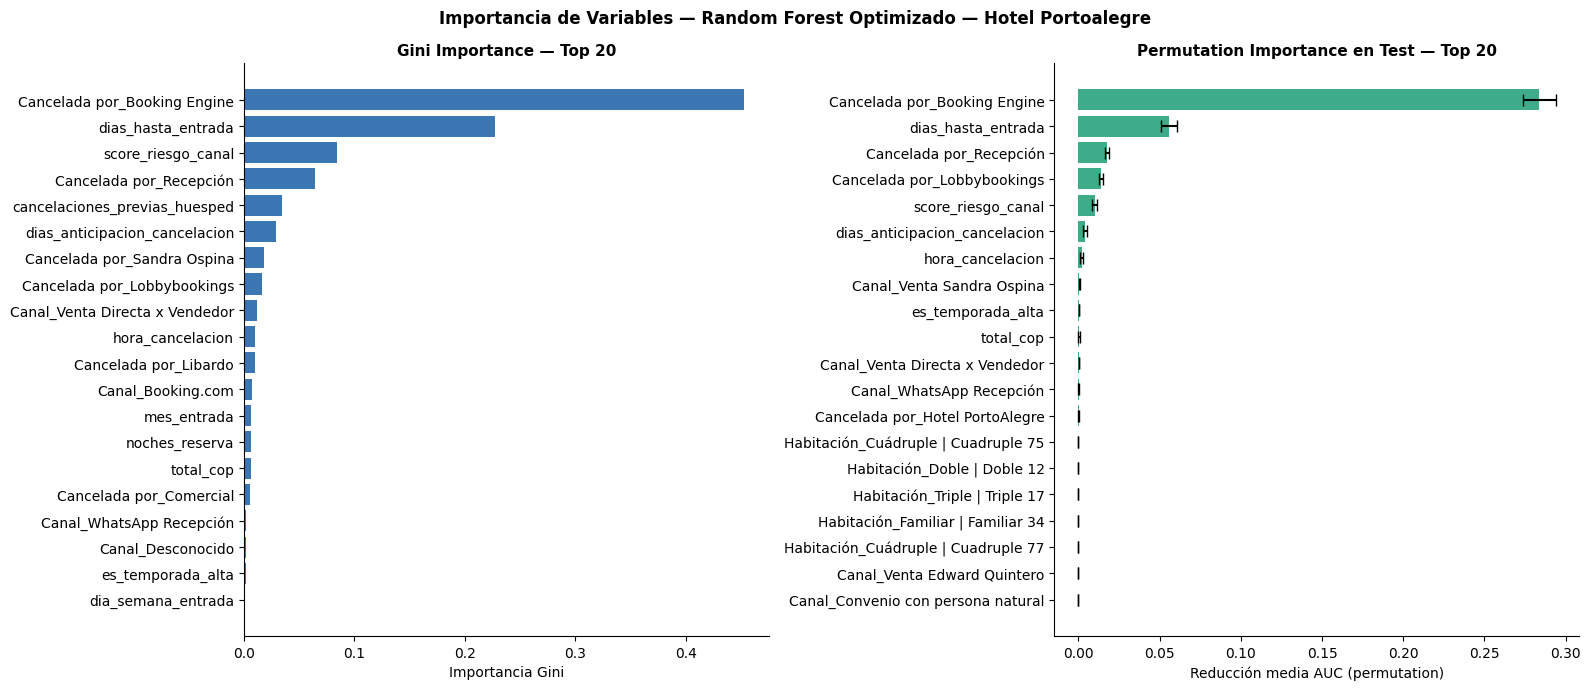

Top 10 por Permutation Importance (más confiable):


,Feature,Perm_Mean,Perm_Std
31,Cancelada por_Booking Engine,0.2836,0.0101
1,dias_hasta_entrada,0.0558,0.0050
39,Cancelada por_Recepción,0.0175,0.0014
36,Cancelada por_Lobbybookings,0.0137,0.0012
10,score_riesgo_canal,0.0099,0.0015
2,dias_anticipacion_cancelacion,0.0040,0.0015
6,hora_cancelacion,0.0019,0.0011
25,Canal_Venta Sandra Ospina,0.0006,0.0002
8,es_temporada_alta,0.0003,0.0002
7,total_cop,0.0002,0.0005


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

rf_clf_final = rf_best.named_steps['clf']
feat_names   = X_train.columns.tolist()

# Gini Importance
gini_imp = pd.DataFrame({'Feature': feat_names,
                          'Gini':    rf_clf_final.feature_importances_}
                        ).sort_values('Gini', ascending=False)

# Permutation Importance en TEST
perm_result = permutation_importance(
    rf_best, X_test, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=-1
)
perm_imp = pd.DataFrame({'Feature': feat_names,
                          'Perm_Mean': perm_result.importances_mean,
                          'Perm_Std':  perm_result.importances_std}
                        ).sort_values('Perm_Mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top20_g = gini_imp.head(20)
axes[0].barh(top20_g['Feature'], top20_g['Gini'], color='#185FA5', alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_title('Gini Importance — Top 20', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Importancia Gini')
axes[0].spines[['top','right']].set_visible(False)

top20_p = perm_imp.head(20)
axes[1].barh(top20_p['Feature'], top20_p['Perm_Mean'],
             xerr=top20_p['Perm_Std'], color='#1D9E75', alpha=0.85, capsize=4)
axes[1].invert_yaxis()
axes[1].set_title('Permutation Importance en Test — Top 20', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Reducción media AUC (permutation)')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Importancia de Variables — Random Forest Optimizado — Hotel Portoalegre',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 por Permutation Importance (más confiable):')
display(perm_imp.head(10).round(4))


## Gradient Boosting — XGBoost

> XGBoost usa boosting secuencial: cada árbol corrige los errores del anterior.
> A diferencia de Random Forest (bagging paralelo), el boosting tiene mayor
> capacidad de capturar patrones complejos pero requiere regularización explícita.
>
> **SMOTE sigue dentro del pipeline** para evitar que las muestras sintéticas
> contaminen los folds de validación cruzada.

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

pipe_xgb = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   XGBClassifier(
        random_state      = 42,
        eval_metric       = 'logloss',
        use_label_encoder = False,
        verbosity         = 0,
        tree_method       = 'hist',
        n_jobs            = 1,
    ))
])

# ── Espacio de búsqueda con regularización más agresiva ──────────────────────
param_dist_xgb = {
    'clf__n_estimators'     : randint(300, 600),   # más árboles
    'clf__max_depth'        : randint(3, 5),        # techo bajado de 6 → 4
    'clf__min_child_weight' : randint(10, 30),      # piso subido de 3 → 10
    'clf__gamma'            : uniform(0.2, 0.5),    # más restrictivo, era 0–0.4
    'clf__learning_rate'    : uniform(0.01, 0.05),  # techo bajado de 0.15 → 0.06
    'clf__subsample'        : uniform(0.5, 0.25),   # bajado de 0.6–0.9 → 0.5–0.75
    'clf__colsample_bytree' : uniform(0.4, 0.25),   # bajado de 0.5–0.9 → 0.4–0.65
    'clf__reg_alpha'        : uniform(0.5, 2.0),    # piso subido de 0 → 0.5
    'clf__reg_lambda'       : uniform(3, 7),         # piso subido de 1 → 3
}

skf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

gs_xgb = RandomizedSearchCV(
    estimator           = pipe_xgb,
    param_distributions = param_dist_xgb,
    n_iter              = 40,           # subido de 30 → 40 para mejor exploración
    cv                  = skf10,
    scoring             = 'f1_weighted',
    n_jobs              = -1,
    verbose             = 1,
    random_state        = 42
)

print('Iniciando RandomizedSearch XGBoost (40 iter × 10 folds = 400 fits)...')
gs_xgb.fit(X_train, y_train)
print(f'\nMejores parámetros XGBoost: {gs_xgb.best_params_}')
print(f'Mejor F1 ponderado CV     : {gs_xgb.best_score_:.4f}')
xgb_best = gs_xgb.best_estimator_


Iniciando RandomizedSearch XGBoost (40 iter × 10 folds = 400 fits)...
Fitting 10 folds for each of 40 candidates, totalling 400 fits

Mejores parámetros XGBoost: {'clf__colsample_bytree': np.float64(0.6038653571137086), 'clf__gamma': np.float64(0.5534286719238086), 'clf__learning_rate': np.float64(0.04645035840204937), 'clf__max_depth': 3, 'clf__min_child_weight': 14, 'clf__n_estimators': 530, 'clf__reg_alpha': np.float64(1.802154051003889), 'clf__reg_lambda': np.float64(9.404717728806466), 'clf__subsample': np.float64(0.7125096444474498)}
Mejor F1 ponderado CV     : 0.9305


=== XGBoost — MÉTRICAS EN TEST ===
Accuracy : 0.8895
AUC-ROC  : 0.9166
Recall   : 0.8124
F1 pond. : 0.8884

              precision    recall  f1-score   support

    No prob.       0.87      0.95      0.91       599
Problemática       0.93      0.81      0.87       469

    accuracy                           0.89      1068
   macro avg       0.90      0.88      0.89      1068
weighted avg       0.89      0.89      0.89      1068

AUC Train: 0.9857 | AUC Test: 0.9166 | Gap: 0.0690 ✅ OK


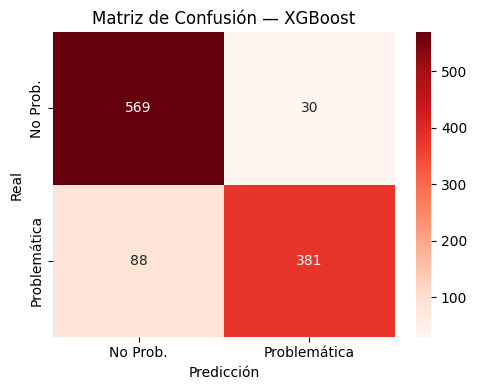

In [ ]:
from sklearn.metrics import (accuracy_score, roc_auc_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_xgb       = xgb_best.predict(X_test)
y_proba_xgb      = xgb_best.predict_proba(X_test)[:, 1]
y_train_pred_xgb = xgb_best.predict(X_train)
y_train_proba_xgb= xgb_best.predict_proba(X_train)[:, 1]

auc_test_xgb  = roc_auc_score(y_test,  y_proba_xgb)
auc_train_xgb = roc_auc_score(y_train, y_train_proba_xgb)
gap_xgb       = auc_train_xgb - auc_test_xgb

print('=== XGBoost — MÉTRICAS EN TEST ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'AUC-ROC  : {auc_test_xgb:.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_xgb):.4f}')
print(f'F1 pond. : {f1_score(y_test, y_pred_xgb, average="weighted"):.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['No prob.', 'Problemática']))
print(f'AUC Train: {auc_train_xgb:.4f} | AUC Test: {auc_test_xgb:.4f} | Gap: {gap_xgb:.4f}',
      '✅ OK' if gap_xgb < 0.10 else '⚠ Moderado')

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Prob.', 'Problemática'],
            yticklabels=['No Prob.', 'Problemática'], ax=ax)
ax.set_title('Matriz de Confusión — XGBoost')
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.tight_layout(); plt.show()


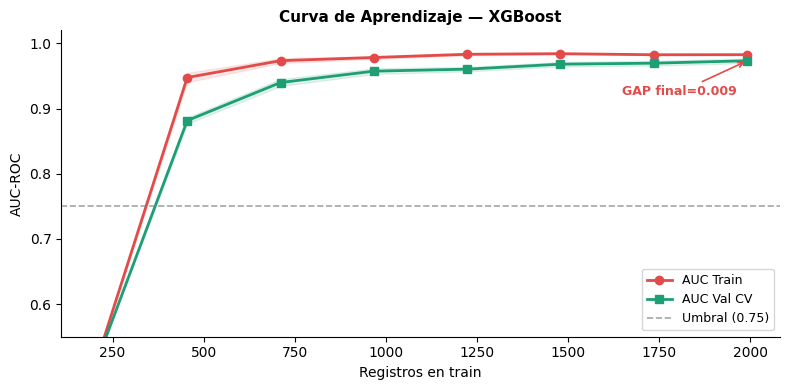

In [ ]:
# ── Curva de aprendizaje XGBoost ─────────────────────────────────────────────
from sklearn.model_selection import learning_curve
import numpy as np

xgb_clf = xgb_best.named_steps['clf']
train_sizes_xgb, tr_sc_xgb, val_sc_xgb = learning_curve(
    xgb_clf, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)

tr_mean_xgb  = tr_sc_xgb.mean(axis=1)
val_mean_xgb = val_sc_xgb.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_sizes_xgb, tr_mean_xgb,  'o-', color='#E24B4A', lw=2, label='AUC Train')
ax.fill_between(train_sizes_xgb,
                tr_mean_xgb - tr_sc_xgb.std(axis=1),
                tr_mean_xgb + tr_sc_xgb.std(axis=1), alpha=0.12, color='#E24B4A')
ax.plot(train_sizes_xgb, val_mean_xgb, 's-', color='#1D9E75', lw=2, label='AUC Val CV')
ax.fill_between(train_sizes_xgb,
                val_mean_xgb - val_sc_xgb.std(axis=1),
                val_mean_xgb + val_sc_xgb.std(axis=1), alpha=0.12, color='#1D9E75')
ax.axhline(0.75, color='gray', linestyle='--', lw=1.2, alpha=0.7, label='Umbral (0.75)')
ax.set_xlabel('Registros en train'); ax.set_ylabel('AUC-ROC')
ax.set_title('Curva de Aprendizaje — XGBoost', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(0.55, 1.02)
ax.spines[['top','right']].set_visible(False)
gap_final_xgb = tr_mean_xgb[-1] - val_mean_xgb[-1]
ax.annotate(f'GAP final={gap_final_xgb:.3f}',
            xy=(train_sizes_xgb[-1], val_mean_xgb[-1]),
            xytext=(-90, -25), textcoords='offset points', fontsize=9,
            color='#E24B4A', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E24B4A', lw=1.2))
plt.tight_layout(); plt.show()


## Early Stopping — XGBoost y LightGBM

> El early stopping detiene el entrenamiento cuando la métrica de validación
> deja de mejorar durante N rondas consecutivas. Esto evita que el modelo
> siga memorizando el conjunto de entrenamiento (overfitting) más allá del
> punto óptimo de generalización.
>
> **Implementación**: se separa un 15% de train como validación interna.
> SMOTE se aplica manualmente (no en pipeline) para que early stopping
> pueda evaluar sobre datos reales sin sintéticos.

In [ ]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, recall_score, f1_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# ── Separar validación interna desde train (15%) ──────────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

# ── Aplicar SMOTE solo sobre X_tr (no contaminar X_val) ──────────────────────
smote = SMOTE(random_state=42)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

print(f'Train (post-SMOTE): {X_tr_sm.shape} | Val (sin SMOTE): {X_val.shape}')
print(f'Balance train: {y_tr_sm.mean()*100:.1f}% | Balance val: {y_val.mean()*100:.1f}%')

# ── XGBoost con Early Stopping ────────────────────────────────────────────────
xgb_es = XGBClassifier(
    n_estimators          = 1000,
    learning_rate         = 0.02,
    max_depth             = 4,
    min_child_weight      = 15,
    gamma                 = 0.3,
    subsample             = 0.65,
    colsample_bytree      = 0.5,
    reg_alpha             = 1.0,
    reg_lambda            = 5.0,
    early_stopping_rounds = 40,
    eval_metric           = 'auc',
    random_state          = 42,
    verbosity             = 0,
    tree_method           = 'hist',
    n_jobs                = 1,
)
xgb_es.fit(X_tr_sm, y_tr_sm,
           eval_set=[(X_val, y_val)],
           verbose=False)
print(f'\nXGBoost — Mejor iteración (early stopping): {xgb_es.best_iteration}')

# ── LightGBM con Early Stopping ───────────────────────────────────────────────
import lightgbm as lgb
lgb_es = LGBMClassifier(
    n_estimators         = 1000,
    learning_rate        = 0.02,
    num_leaves           = 20,
    max_depth            = 4,
    min_child_samples    = 60,
    subsample            = 0.65,
    colsample_bytree     = 0.5,
    reg_alpha            = 1.0,
    reg_lambda           = 5.0,
    min_split_gain       = 0.2,
    random_state         = 42,
    verbose              = -1,
    n_jobs               = -1,
)
lgb_es.fit(X_tr_sm, y_tr_sm,
           eval_set=[(X_val, y_val)],
           callbacks=[lgb.early_stopping(40, verbose=False),
                      lgb.log_evaluation(-1)])
print(f'LightGBM — Mejor iteración (early stopping): {lgb_es.best_iteration_}')

# ── Evaluar en test ───────────────────────────────────────────────────────────
y_pred_xgb_es   = xgb_es.predict(X_test)
y_proba_xgb_es  = xgb_es.predict_proba(X_test)[:,1]
y_pred_lgb_es   = lgb_es.predict(X_test)
y_proba_lgb_es  = lgb_es.predict_proba(X_test)[:,1]

# Train preds para GAP
y_pred_xgb_es_tr  = xgb_es.predict(X_train)
y_proba_xgb_es_tr = xgb_es.predict_proba(X_train)[:,1]
y_pred_lgb_es_tr  = lgb_es.predict(X_train)
y_proba_lgb_es_tr = lgb_es.predict_proba(X_train)[:,1]

import pandas as pd
resultados_es = []
for nombre, y_p, y_pp, y_tr_p, y_tr_pp in [
    ('XGBoost+ES',  y_pred_xgb_es,  y_proba_xgb_es,  y_pred_xgb_es_tr,  y_proba_xgb_es_tr),
    ('LightGBM+ES', y_pred_lgb_es,  y_proba_lgb_es,  y_pred_lgb_es_tr,  y_proba_lgb_es_tr),
]:
    auc_te  = roc_auc_score(y_test,  y_pp)
    auc_tr  = roc_auc_score(y_train, y_tr_pp)
    rec_te  = recall_score(y_test, y_p)
    gap_auc = auc_tr - auc_te
    resultados_es.append({
        'Modelo'    : nombre,
        'AUC Test'  : round(auc_te, 4),
        'AUC Train' : round(auc_tr, 4),
        'Gap AUC'   : round(gap_auc, 4),
        'Recall Test': round(rec_te, 4),
        'Cumple AUC'   : '✅' if auc_te  >= 0.75 else '❌',
        'Cumple Recall': '✅' if rec_te  >= 0.70 else '❌',
        'Overfitting'  : '✅ OK' if gap_auc < 0.05 else '⚠ Moderado' if gap_auc < 0.10 else '❌ Alto',
    })

df_es = pd.DataFrame(resultados_es)
print('\n=== COMPARATIVO CON EARLY STOPPING ===')
display(df_es)
print('\nComparar con los modelos sin Early Stopping en df_comp para ver mejora en GAP.')


Train (post-SMOTE): (2682, 88) | Val (sin SMOTE): (374, 88)
Balance train: 50.0% | Balance val: 36.6%

XGBoost — Mejor iteración (early stopping): 612
LightGBM — Mejor iteración (early stopping): 1000

=== COMPARATIVO CON EARLY STOPPING ===


,Modelo,AUC Test,AUC Train,Gap AUC,Recall Test,Cumple AUC,Cumple Recall,Overfitting
0,XGBoost+ES,0.9185,0.9843,0.0658,0.8188,✅,✅,⚠ Moderado
1,LightGBM+ES,0.9242,0.9925,0.0683,0.8166,✅,✅,⚠ Moderado



Comparar con los modelos sin Early Stopping en df_comp para ver mejora en GAP.


## Gradient Boosting — LightGBM

> LightGBM usa **leaf-wise growth** (crece por hoja con mayor ganancia) vs.
> el **level-wise** de XGBoost. Esto lo hace más rápido y eficiente en memoria,
> especialmente con datasets de alta cardinalidad categórica como este.
> Los hiperparámetros clave de regularización son `num_leaves`, `min_child_samples`,
> `reg_alpha` y `reg_lambda`.

In [ ]:
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

pipe_lgb = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   LGBMClassifier(
        random_state = 42,
        n_jobs       = -1,
        verbose      = -1,
    ))
])

# ── Espacio de búsqueda con regularización más agresiva ──────────────────────
param_dist_lgb = {
    'clf__n_estimators'      : randint(300, 600),
    'clf__num_leaves'        : randint(10, 25),     # bajado drásticamente de 60 → 25
    'clf__max_depth'         : randint(3, 5),        # techo bajado de 8 → 4
    'clf__learning_rate'     : uniform(0.01, 0.05),  # techo bajado de 0.15 → 0.06
    'clf__min_child_samples' : randint(40, 100),     # piso subido de 10 → 40
    'clf__subsample'         : uniform(0.5, 0.25),
    'clf__colsample_bytree'  : uniform(0.4, 0.25),
    'clf__reg_alpha'         : uniform(0.5, 2.0),    # piso subido de 0 → 0.5
    'clf__reg_lambda'        : uniform(3, 7),         # piso subido de 1 → 3
    'clf__min_split_gain'    : uniform(0.1, 0.5),    # nueva — penaliza splits débiles
}

gs_lgb = RandomizedSearchCV(
    estimator           = pipe_lgb,
    param_distributions = param_dist_lgb,
    n_iter              = 40,           # subido de 30 → 40
    cv                  = StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    scoring             = 'f1_weighted',
    n_jobs              = -1,
    verbose             = 1,
    random_state        = 42
)

print('Iniciando RandomizedSearch LightGBM (40 iter × 10 folds = 400 fits)...')
gs_lgb.fit(X_train, y_train)
print(f'\nMejores parámetros LightGBM: {gs_lgb.best_params_}')
print(f'Mejor F1 ponderado CV      : {gs_lgb.best_score_:.4f}')
lgb_best = gs_lgb.best_estimator_


Iniciando RandomizedSearch LightGBM (40 iter × 10 folds = 400 fits)...
Fitting 10 folds for each of 40 candidates, totalling 400 fits

Mejores parámetros LightGBM: {'clf__colsample_bytree': np.float64(0.5041274869675916), 'clf__learning_rate': np.float64(0.05416401294594342), 'clf__max_depth': 4, 'clf__min_child_samples': 97, 'clf__min_split_gain': np.float64(0.16104397735033668), 'clf__n_estimators': 530, 'clf__num_leaves': 23, 'clf__reg_alpha': np.float64(0.7201038490553535), 'clf__reg_lambda': np.float64(4.595546137793592), 'clf__subsample': np.float64(0.606776947156564)}
Mejor F1 ponderado CV      : 0.9355


=== LightGBM — MÉTRICAS EN TEST ===
Accuracy : 0.8858
AUC-ROC  : 0.9141
Recall   : 0.8209
F1 pond. : 0.8849

              precision    recall  f1-score   support

    No prob.       0.87      0.94      0.90       599
Problemática       0.91      0.82      0.86       469

    accuracy                           0.89      1068
   macro avg       0.89      0.88      0.88      1068
weighted avg       0.89      0.89      0.88      1068

AUC Train: 0.9941 | AUC Test: 0.9141 | Gap: 0.0800 ✅ OK


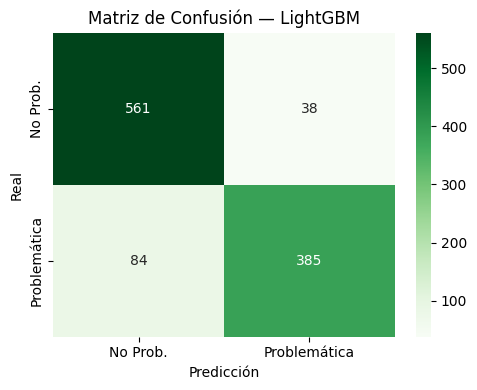

In [ ]:
y_pred_lgb        = lgb_best.predict(X_test)
y_proba_lgb       = lgb_best.predict_proba(X_test)[:, 1]
y_train_pred_lgb  = lgb_best.predict(X_train)
y_train_proba_lgb = lgb_best.predict_proba(X_train)[:, 1]

auc_test_lgb  = roc_auc_score(y_test,  y_proba_lgb)
auc_train_lgb = roc_auc_score(y_train, y_train_proba_lgb)
gap_lgb       = auc_train_lgb - auc_test_lgb

print('=== LightGBM — MÉTRICAS EN TEST ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lgb):.4f}')
print(f'AUC-ROC  : {auc_test_lgb:.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_lgb):.4f}')
print(f'F1 pond. : {f1_score(y_test, y_pred_lgb, average="weighted"):.4f}')
print()
print(classification_report(y_test, y_pred_lgb, target_names=['No prob.', 'Problemática']))
print(f'AUC Train: {auc_train_lgb:.4f} | AUC Test: {auc_test_lgb:.4f} | Gap: {gap_lgb:.4f}',
      '✅ OK' if gap_lgb < 0.10 else '⚠ Moderado')

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lgb), annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Prob.', 'Problemática'],
            yticklabels=['No Prob.', 'Problemática'], ax=ax)
ax.set_title('Matriz de Confusión — LightGBM')
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.tight_layout(); plt.show()


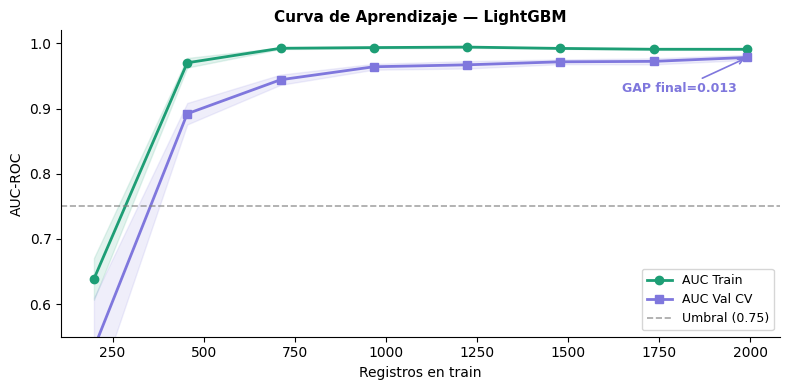

In [ ]:
# ── Curva de aprendizaje LightGBM ────────────────────────────────────────────
lgb_clf = lgb_best.named_steps['clf']
train_sizes_lgb, tr_sc_lgb, val_sc_lgb = learning_curve(
    lgb_clf, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)

tr_mean_lgb  = tr_sc_lgb.mean(axis=1)
val_mean_lgb = val_sc_lgb.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_sizes_lgb, tr_mean_lgb,  'o-', color='#1D9E75', lw=2, label='AUC Train')
ax.fill_between(train_sizes_lgb,
                tr_mean_lgb - tr_sc_lgb.std(axis=1),
                tr_mean_lgb + tr_sc_lgb.std(axis=1), alpha=0.12, color='#1D9E75')
ax.plot(train_sizes_lgb, val_mean_lgb, 's-', color='#7F77DD', lw=2, label='AUC Val CV')
ax.fill_between(train_sizes_lgb,
                val_mean_lgb - val_sc_lgb.std(axis=1),
                val_mean_lgb + val_sc_lgb.std(axis=1), alpha=0.12, color='#7F77DD')
ax.axhline(0.75, color='gray', linestyle='--', lw=1.2, alpha=0.7, label='Umbral (0.75)')
ax.set_xlabel('Registros en train'); ax.set_ylabel('AUC-ROC')
ax.set_title('Curva de Aprendizaje — LightGBM', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(0.55, 1.02)
ax.spines[['top','right']].set_visible(False)
gap_final_lgb = tr_mean_lgb[-1] - val_mean_lgb[-1]
ax.annotate(f'GAP final={gap_final_lgb:.3f}',
            xy=(train_sizes_lgb[-1], val_mean_lgb[-1]),
            xytext=(-90, -25), textcoords='offset points', fontsize=9,
            color='#7F77DD', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#7F77DD', lw=1.2))
plt.tight_layout(); plt.show()


## Comparación de Modelos — RF vs XGBoost vs LightGBM

> **Criterio de selección**: se prioriza el modelo con mayor AUC en test
> que cumpla ambos objetivos técnicos (AUC ≥ 0.75, Recall ≥ 0.70),
> con menor GAP AUC como desempate (menor riesgo de overfitting).

=== TABLA COMPARATIVA — RF vs XGBoost vs LightGBM ===


,Modelo,AUC Train,AUC Test,Gap AUC,Recall Train,Recall Test,Accuracy Train,Accuracy Test,Gap Accuracy,F1 pond. Train,F1 pond. Test,Cumple AUC,Cumple Recall,Overfitting Risk
0,Random Forest,0.9821,0.9170,0.0651,0.8399,0.7719,0.9325,0.8820,0.0505,0.9313,0.8800,✅,✅,⚠ Moderado
1,XGBoost,0.9857,0.9166,0.0690,0.8980,0.8124,0.9438,0.8895,0.0543,0.9435,0.8884,✅,✅,⚠ Moderado
2,LightGBM,0.9941,0.9141,0.0800,0.9320,0.8209,0.9639,0.8858,0.0781,0.9637,0.8849,✅,✅,⚠ Moderado


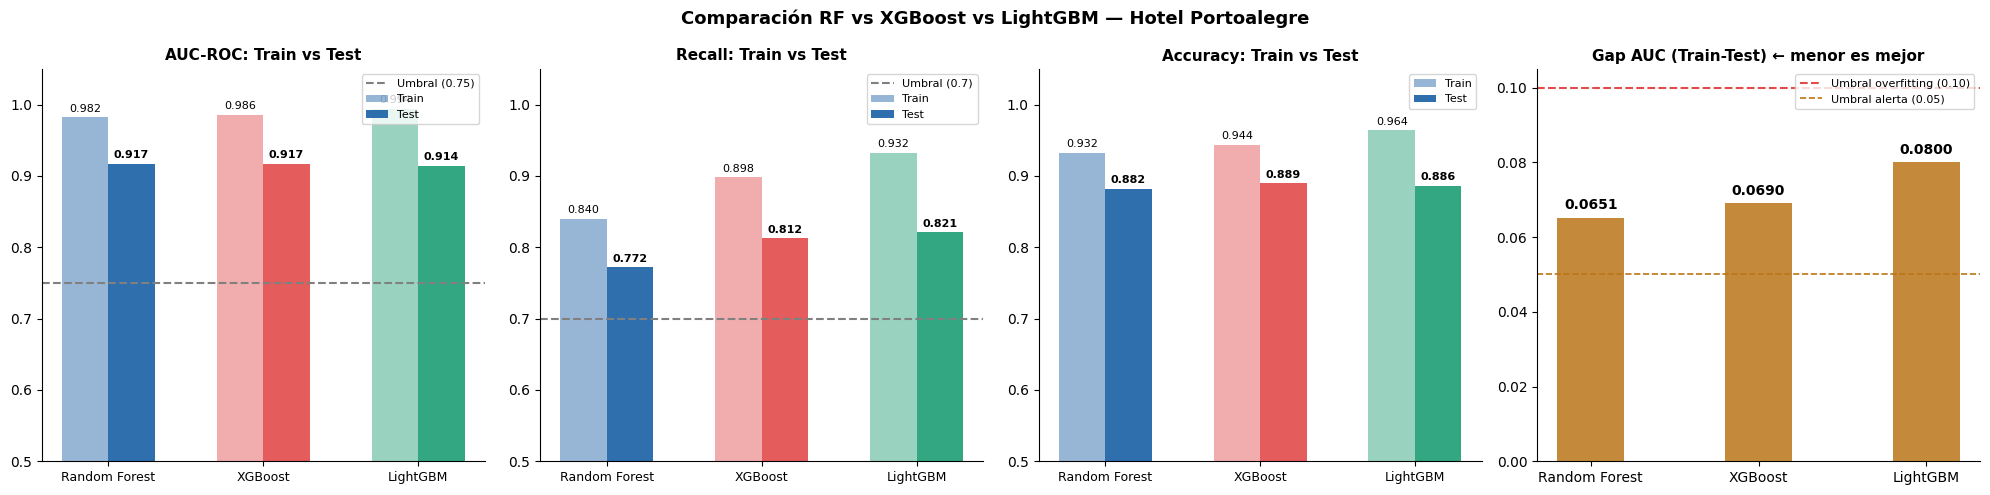

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, recall_score, f1_score,
                             accuracy_score, roc_curve)

AUC_OBJ    = 0.75
RECALL_OBJ = 0.70   # CORREGIDO: el objetivo es 0.70, no 0.75
UMBRAL_OVF = 0.10

# ── Tabla comparativa completa ────────────────────────────────────────────────
resultados = []
for nombre, y_p, y_pp, y_tr_p, y_tr_pp in [
    ('Random Forest', y_pred_opt,  y_proba_opt,  rf_best.predict(X_train),  rf_best.predict_proba(X_train)[:,1]),
    ('XGBoost',       y_pred_xgb,  y_proba_xgb,  y_train_pred_xgb,          y_train_proba_xgb),
    ('LightGBM',      y_pred_lgb,  y_proba_lgb,  y_train_pred_lgb,          y_train_proba_lgb),
]:
    auc_te  = roc_auc_score(y_test,  y_pp)
    auc_tr  = roc_auc_score(y_train, y_tr_pp)
    rec_te  = recall_score(y_test,  y_p)
    rec_tr  = recall_score(y_train, y_tr_p)
    f1_te   = f1_score(y_test,  y_p,   average='weighted')
    f1_tr   = f1_score(y_train, y_tr_p, average='weighted')
    acc_te  = accuracy_score(y_test,  y_p)
    acc_tr  = accuracy_score(y_train, y_tr_p)
    gap_auc = auc_tr - auc_te
    gap_acc = acc_tr - acc_te
    resultados.append({
        'Modelo'           : nombre,
        'AUC Test'         : round(auc_te,  4),
        'AUC Train'        : round(auc_tr,  4),
        'Gap AUC'          : round(gap_auc, 4),
        'Recall Test'      : round(rec_te,  4),
        'Recall Train'     : round(rec_tr,  4),
        'Accuracy Test'    : round(acc_te,  4),
        'Accuracy Train'   : round(acc_tr,  4),
        'Gap Accuracy'     : round(gap_acc, 4),
        'F1 pond. Test'    : round(f1_te,   4),
        'F1 pond. Train'   : round(f1_tr,   4),
        'Cumple AUC'       : '✅' if auc_te  >= AUC_OBJ    else '❌',
        'Cumple Recall'    : '✅' if rec_te  >= RECALL_OBJ  else '❌',
        'Overfitting Risk' : '✅ OK'       if gap_auc < 0.05 else
                             '⚠ Moderado' if gap_auc < 0.10 else '❌ Alto',
    })

df_comp = pd.DataFrame(resultados)  # CORRECCIÓN: era 'df_comp = p' (código truncado)
print('=== TABLA COMPARATIVA — RF vs XGBoost vs LightGBM ===')
display(df_comp[['Modelo','AUC Train','AUC Test','Gap AUC',
                 'Recall Train','Recall Test',
                 'Accuracy Train','Accuracy Test','Gap Accuracy',
                 'F1 pond. Train','F1 pond. Test',
                 'Cumple AUC','Cumple Recall','Overfitting Risk']])

# ── Gráfico comparativo cuádruple ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
modelos = df_comp['Modelo'].tolist()
colores = ['#185FA5', '#E24B4A', '#1D9E75']
x       = np.arange(len(modelos))
bar_w   = 0.30

def panel_barras(ax, vals_train, vals_test, titulo, umbral=None, umbral_label=None):
    ax.bar(x - bar_w/2, vals_train, bar_w, color=colores, alpha=0.45, label='Train')
    ax.bar(x + bar_w/2, vals_test,  bar_w, color=colores, alpha=0.90, label='Test')
    if umbral:
        ax.axhline(umbral, color='gray', linestyle='--', lw=1.5,
                   label=umbral_label or f'Umbral ({umbral})')
    ax.set_xticks(x); ax.set_xticklabels(modelos, fontsize=9)
    ax.set_ylim(0.5, 1.05); ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
    for i, (tr, te) in enumerate(zip(vals_train, vals_test)):
        ax.text(i-bar_w/2, tr+0.008, f'{tr:.3f}', ha='center', fontsize=8)
        ax.text(i+bar_w/2, te+0.008, f'{te:.3f}', ha='center', fontsize=8, fontweight='bold')

panel_barras(axes[0], df_comp['AUC Train'],      df_comp['AUC Test'],
             'AUC-ROC: Train vs Test', umbral=AUC_OBJ)
panel_barras(axes[1], df_comp['Recall Train'],   df_comp['Recall Test'],
             'Recall: Train vs Test',  umbral=RECALL_OBJ)
panel_barras(axes[2], df_comp['Accuracy Train'], df_comp['Accuracy Test'],
             'Accuracy: Train vs Test')

gap_colors = ['#E24B4A' if g>=0.10 else '#BA7517' if g>=0.05 else '#1D9E75'
              for g in df_comp['Gap AUC']]
bars_gap = axes[3].bar(modelos, df_comp['Gap AUC'], color=gap_colors, alpha=0.85, width=0.4)
axes[3].axhline(UMBRAL_OVF, color='#E24B4A', linestyle='--', lw=1.5, label='Umbral overfitting (0.10)')
axes[3].axhline(0.05,       color='#BA7517', linestyle='--', lw=1.2, label='Umbral alerta (0.05)')
axes[3].set_title('Gap AUC (Train-Test) ← menor es mejor', fontsize=11, fontweight='bold')
axes[3].bar_label(bars_gap, fmt='%.4f', padding=4, fontsize=10, fontweight='bold')
axes[3].legend(fontsize=8); axes[3].spines[['top','right']].set_visible(False)

plt.suptitle('Comparación RF vs XGBoost vs LightGBM — Hotel Portoalegre',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


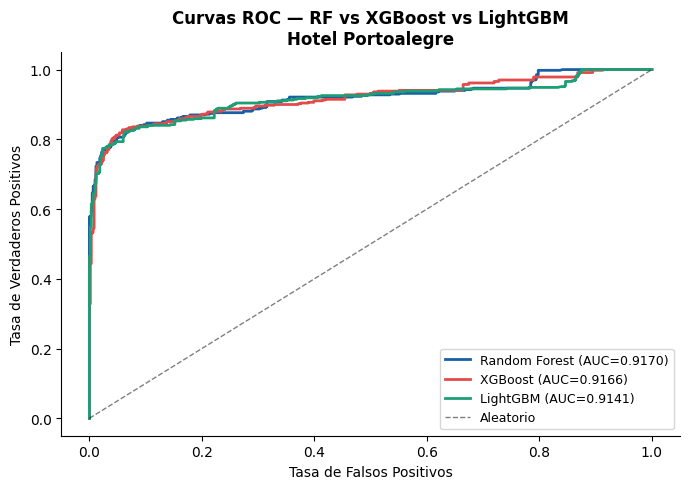

In [ ]:
# ── Curvas ROC superpuestas ───────────────────────────────────────────────────
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(7, 5))
colores_roc = {'Random Forest': '#185FA5', 'XGBoost': '#E24B4A', 'LightGBM': '#1D9E75'}
for nombre, y_pp in [('Random Forest', y_proba_opt),
                     ('XGBoost',       y_proba_xgb),
                     ('LightGBM',      y_proba_lgb)]:
    fpr_r, tpr_r, _ = roc_curve(y_test, y_pp)
    auc_r = roc_auc_score(y_test, y_pp)
    ax.plot(fpr_r, tpr_r, lw=2, color=colores_roc[nombre],
            label=f'{nombre} (AUC={auc_r:.4f})')

ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC — RF vs XGBoost vs LightGBM\nHotel Portoalegre',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


## Selección del Mejor Modelo — Criterio CRISP-DM §4.4

**Criterios de selección (en orden de prioridad):**
1. Cumplir OB1: AUC-ROC ≥ 0.75 en test
2. Cumplir OB2: Recall ≥ 0.70 en test
3. Menor GAP AUC (mejor generalización, menor riesgo de overfitting)
4. Mayor AUC en test como desempate

In [ ]:
import pandas as pd

AUC_OBJ    = 0.75
RECALL_OBJ = 0.70

candidatos = df_comp[
    (df_comp['Cumple AUC'] == '✅') &
    (df_comp['Cumple Recall'] == '✅')
].copy()

ganador = candidatos.sort_values(
    ['Gap AUC', 'AUC Test'], ascending=[True, False]
).iloc[0]

print('=' * 65)
print('SELECCIÓN DEL MODELO — CRISP-DM §4.4 (Assess Model)')
print('=' * 65)
print()
for _, row in df_comp.iterrows():
    es_ganador = ' ← MODELO SELECCIONADO ✅' if row['Modelo'] == ganador['Modelo'] else ''
    print(f"{row['Modelo']}{es_ganador}")
    print(f"  AUC Test    : {row['AUC Test']:.4f}  (objetivo ≥ {AUC_OBJ})  → {row['Cumple AUC']}")
    print(f"  Recall Test : {row['Recall Test']:.4f}  (objetivo ≥ {RECALL_OBJ}) → {row['Cumple Recall']}")
    print(f"  Gap AUC     : {row['Gap AUC']:.4f}  (umbral < 0.10)         → {row['Overfitting Risk']}")
    print(f"  F1 pond.    : {row['F1 pond. Test']:.4f}")
    print()

print()
print('CRITERIO DE SELECCIÓN:')
print('  Cumple ambos objetivos técnicos + menor Gap AUC (menor riesgo overfitting)')
print()
print(f"→ MODELO SELECCIONADO PARA PRODUCCIÓN: {ganador['Modelo']}")
print(f"  AUC={ganador['AUC Test']:.4f} | Recall={ganador['Recall Test']:.4f} | Gap={ganador['Gap AUC']:.4f}")
print()
print('JUSTIFICACIÓN:')
print(f"  {ganador['Modelo']} cumple ambos criterios técnicos y presenta el menor Gap AUC")
print(f"  ({ganador['Gap AUC']:.4f}), lo que indica que sus predicciones generalizan mejor")
print( "  a datos nuevos del hotel sin memorizar el conjunto de entrenamiento.")
print( "  Esto es crítico en el contexto hotelero, donde las reservas futuras")
print( "  pueden tener perfiles diferentes a los patrones históricos aprendidos.")


SELECCIÓN DEL MODELO — CRISP-DM §4.4 (Assess Model)

Random Forest ← MODELO SELECCIONADO ✅
  AUC Test    : 0.9170  (objetivo ≥ 0.75)  → ✅
  Recall Test : 0.7719  (objetivo ≥ 0.7) → ✅
  Gap AUC     : 0.0651  (umbral < 0.10)         → ⚠ Moderado
  F1 pond.    : 0.8800

XGBoost
  AUC Test    : 0.9166  (objetivo ≥ 0.75)  → ✅
  Recall Test : 0.8124  (objetivo ≥ 0.7) → ✅
  Gap AUC     : 0.0690  (umbral < 0.10)         → ⚠ Moderado
  F1 pond.    : 0.8884

LightGBM
  AUC Test    : 0.9141  (objetivo ≥ 0.75)  → ✅
  Recall Test : 0.8209  (objetivo ≥ 0.7) → ✅
  Gap AUC     : 0.0800  (umbral < 0.10)         → ⚠ Moderado
  F1 pond.    : 0.8849


CRITERIO DE SELECCIÓN:
  Cumple ambos objetivos técnicos + menor Gap AUC (menor riesgo overfitting)

→ MODELO SELECCIONADO PARA PRODUCCIÓN: Random Forest
  AUC=0.9170 | Recall=0.7719 | Gap=0.0651

JUSTIFICACIÓN:
  Random Forest cumple ambos criterios técnicos y presenta el menor Gap AUC
  (0.0651), lo que indica que sus predicciones generalizan mejor
  a dat

## Verificación de Objetivos — CRISP-DM §4.4 (Assess Model)

**Objetivos técnicos (Data Mining Success Criteria):**
- **OB1**: AUC-ROC ≥ 0.75 en conjunto de prueba
- **OB2**: Recall (clase problemática) ≥ 0.70 en conjunto de prueba

**Objetivo de negocio:**
- **OB3**: Reducción estimada del ingreso perdido por cancelaciones no reemplazadas ≥ 5%
  (calculado como proporción de cancelaciones problemáticas que el modelo detecta correctamente)

Modelo seleccionado : Random Forest
Umbral óptimo       : 0.4667
Tasa reasignación (datos reales >7 días): 44%

EVALUACIÓN FINAL — ASSESS MODEL (CRISP-DM §4.4)


,Objetivo,Valor obtenido,Umbral,Cumple
0,OB1 — AUC-ROC ≥ 0.75,0.917,0.75,✅ SÍ
1,OB2 — Recall ≥ 0.70,0.7719,0.7,✅ SÍ
2,OB3 — Reducción COP perdido ≥ 5%,33.3%,5%,✅ SÍ



  Detalle OB3:
    COP total en riesgo (test)  : $ 436,675,644
    COP recuperado por modelo   : $ 145,482,883
    COP perdido post-modelo     : $ 291,192,761
    Tasa reasignación aplicada  : 44%
    Reducción estimada          : 33.3%


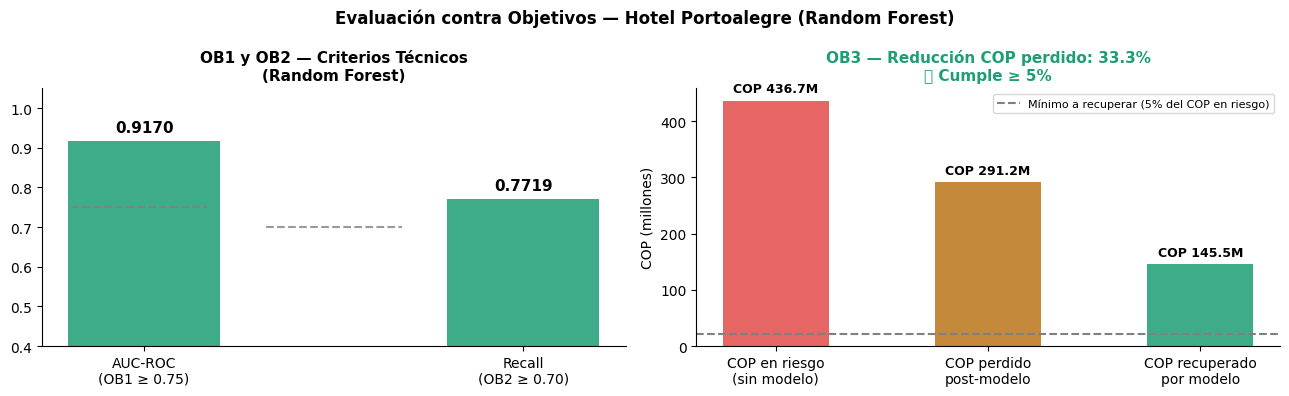


→ Modelo seleccionado: Random Forest
  AUC    = 0.9170   (umbral ≥ 0.75)
  Recall = 0.7719   (umbral ≥ 0.7)
  OB3    = 33.3%      (umbral ≥ 5%)

  Veredicto: ✅ APROBADO — Cumple todos los objetivos


In [ ]:
from sklearn.metrics import roc_auc_score, recall_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

AUC_OBJ    = 0.75
RECALL_OBJ = 0.70
OBJ_NEG    = 0.05

# ── Seleccionar predicciones del modelo ganador (no hardcoded a RF) ───────────
MEJOR_NOMBRE = ganador['Modelo']
if MEJOR_NOMBRE == 'Random Forest':
    y_pred_final  = y_pred_opt
    y_proba_final = y_proba_opt
elif MEJOR_NOMBRE == 'XGBoost':
    y_pred_final  = y_pred_xgb
    y_proba_final = y_proba_xgb
else:  # LightGBM
    y_pred_final  = y_pred_lgb
    y_proba_final = y_proba_lgb

# Umbral óptimo del modelo ganador (Youden J)
from sklearn.metrics import roc_curve
fpr_g, tpr_g, thr_g = roc_curve(y_test, y_proba_final)
opt_idx    = (tpr_g - fpr_g).argmax()
opt_umbral = thr_g[opt_idx]
print(f'Modelo seleccionado : {MEJOR_NOMBRE}')
print(f'Umbral óptimo       : {opt_umbral:.4f}')

# ── OB1 y OB2 ────────────────────────────────────────────────────────────────
auc_final    = roc_auc_score(y_test, y_proba_final)
recall_final = recall_score(y_test, y_pred_final)

# ── OB3 — mismo universo (test), coherente con fórmula del documento ──────────
df_test_ob3 = test_df.copy().reset_index(drop=True)
y_test_r    = y_test.reset_index(drop=True)
y_pred_r    = pd.Series(y_pred_final).reset_index(drop=True)

df_test_ob3['target'] = y_test_r.values
df_test_ob3['pred']   = y_pred_r.values
df_test_ob3['prob']   = y_proba_final

prob_test_ob3 = df_test_ob3[df_test_ob3['target'] == 1].copy()
tp_ob3 = (prob_test_ob3['pred'] == 1)
fn_ob3 = (prob_test_ob3['pred'] == 0)

if 'dias_hasta_entrada' in prob_test_ob3.columns:
    TASA_REASIGNACION = round(
        prob_test_ob3.loc[tp_ob3, 'dias_hasta_entrada'].gt(7).mean(), 2
    )
    print(f'Tasa reasignación (datos reales >7 días): {TASA_REASIGNACION*100:.0f}%')
else:
    TASA_REASIGNACION = 0.60

cop_en_riesgo        = prob_test_ob3['total_cop'].sum()
cop_fn_ob3           = prob_test_ob3.loc[fn_ob3, 'total_cop'].sum()
cop_tp_no_reasignado = prob_test_ob3.loc[tp_ob3, 'total_cop'].sum() * (1 - TASA_REASIGNACION)
cop_perdido_post     = cop_fn_ob3 + cop_tp_no_reasignado
cop_recuperado       = cop_en_riesgo - cop_perdido_post
reduccion_estimada   = (cop_en_riesgo - cop_perdido_post) / cop_en_riesgo * 100

# ── Tabla de objetivos ────────────────────────────────────────────────────────
df_obj = pd.DataFrame([
    {'Objetivo':'OB1 — AUC-ROC ≥ 0.75',
     'Valor obtenido': round(auc_final, 4),
     'Umbral': AUC_OBJ,
     'Cumple': '✅ SÍ' if auc_final >= AUC_OBJ else '❌ NO'},
    {'Objetivo':'OB2 — Recall ≥ 0.70',
     'Valor obtenido': round(recall_final, 4),
     'Umbral': RECALL_OBJ,
     'Cumple': '✅ SÍ' if recall_final >= RECALL_OBJ else '❌ NO'},
    {'Objetivo':'OB3 — Reducción COP perdido ≥ 5%',
     'Valor obtenido': f'{reduccion_estimada:.1f}%',
     'Umbral': '5%',
     'Cumple': '✅ SÍ' if reduccion_estimada >= OBJ_NEG*100 else '❌ NO'},
])

print('\n' + '='*65)
print('EVALUACIÓN FINAL — ASSESS MODEL (CRISP-DM §4.4)')
print('='*65)
display(df_obj)
print(f'\n  Detalle OB3:')
print(f'    COP total en riesgo (test)  : ${cop_en_riesgo:>12,.0f}')
print(f'    COP recuperado por modelo   : ${cop_recuperado:>12,.0f}')
print(f'    COP perdido post-modelo     : ${cop_perdido_post:>12,.0f}')
print(f'    Tasa reasignación aplicada  : {TASA_REASIGNACION*100:.0f}%')
print(f'    Reducción estimada          : {reduccion_estimada:.1f}%')

# ── Gráfico resumen ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

metricas_obj = ['AUC-ROC\n(OB1 ≥ 0.75)', 'Recall\n(OB2 ≥ 0.70)']
valores_obj  = [auc_final, recall_final]
umbrales_obj = [AUC_OBJ, RECALL_OBJ]
colores_obj  = ['#1D9E75' if v>=u else '#E24B4A' for v,u in zip(valores_obj, umbrales_obj)]

bars = axes[0].bar(metricas_obj, valores_obj, color=colores_obj, alpha=0.85, width=0.4)
for u, x in zip(umbrales_obj, [0,1]):
    axes[0].axhline(u, xmin=x/3+0.05, xmax=(x+1)/3-0.05,
                    color='gray', linestyle='--', lw=1.5, alpha=0.8)
axes[0].set_ylim(0.4, 1.05)
axes[0].bar_label(bars, fmt='%.4f', padding=4, fontsize=11, fontweight='bold')
axes[0].set_title(f'OB1 y OB2 — Criterios Técnicos\n({MEJOR_NOMBRE})',
                  fontsize=11, fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)

categorias_ob3 = ['COP en riesgo\n(sin modelo)', 'COP perdido\npost-modelo', 'COP recuperado\npor modelo']
valores_ob3    = [cop_en_riesgo/1e6, cop_perdido_post/1e6, cop_recuperado/1e6]
colores_ob3    = ['#E24B4A', '#BA7517', '#1D9E75']
bars2 = axes[1].bar(categorias_ob3, valores_ob3, color=colores_ob3, alpha=0.85, width=0.5)
axes[1].bar_label(bars2, labels=[f'COP {v:.1f}M' for v in valores_ob3],
                  padding=4, fontsize=9, fontweight='bold')
axes[1].axhline(cop_en_riesgo/1e6 * OBJ_NEG, color='gray', linestyle='--', lw=1.5,
                label='Mínimo a recuperar (5% del COP en riesgo)')
axes[1].set_ylabel('COP (millones)')
color_ob3 = '#1D9E75' if reduccion_estimada>=5 else '#E24B4A'
axes[1].set_title(f'OB3 — Reducción COP perdido: {reduccion_estimada:.1f}%\n'
                  f'{"✅ Cumple ≥ 5%" if reduccion_estimada>=5 else "❌ No cumple < 5%"}',
                  fontsize=11, fontweight='bold', color=color_ob3)
axes[1].legend(fontsize=8); axes[1].spines[['top','right']].set_visible(False)

plt.suptitle(f'Evaluación contra Objetivos — Hotel Portoalegre ({MEJOR_NOMBRE})',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

cumple = (auc_final>=AUC_OBJ) and (recall_final>=RECALL_OBJ) and (reduccion_estimada>=OBJ_NEG*100)
print(f'\n→ Modelo seleccionado: {MEJOR_NOMBRE}')
print(f'  AUC    = {auc_final:.4f}   (umbral ≥ {AUC_OBJ})')
print(f'  Recall = {recall_final:.4f}   (umbral ≥ {RECALL_OBJ})')
print(f'  OB3    = {reduccion_estimada:.1f}%      (umbral ≥ 5%)')
print(f'\n  Veredicto: {"✅ APROBADO — Cumple todos los objetivos" if cumple else "❌ NO CUMPLE todos los objetivos"}')


## 10. Resumen Ejecutivo — *Approved Models* (CRISP-DM)

In [ ]:
# ── RESUMEN EJECUTIVO — MODELO 1 ─────────────────────────────────────────────
# Variables requeridas (deben existir en celdas anteriores):
# df_comp, ganador, opt_umbral, reduccion_estimada, TASA_REASIGNACION
# auc_final, recall_final (del modelo seleccionado)

# Extraer métricas por modelo desde df_comp
def get_metric(modelo, col):
    return df_comp.loc[df_comp['Modelo'] == modelo, col].values[0]

auc_rf  = get_metric('Random Forest', 'AUC Test')
auc_xgb = get_metric('XGBoost',       'AUC Test')
auc_lgb = get_metric('LightGBM',      'AUC Test')

rec_rf  = get_metric('Random Forest', 'Recall Test')
rec_xgb = get_metric('XGBoost',       'Recall Test')
rec_lgb = get_metric('LightGBM',      'Recall Test')

gap_rf  = get_metric('Random Forest', 'Gap AUC')
gap_xgb = get_metric('XGBoost',       'Gap AUC')
gap_lgb = get_metric('LightGBM',      'Gap AUC')

MEJOR_NOMBRE = ganador['Modelo']

print('=' * 75)
print('RESUMEN EJECUTIVO — MODELO 1: PROPENSIÓN A CANCELACIÓN PROBLEMÁTICA')
print('Hotel Portoalegre — Golfo de Morrosquillo')
print('=' * 75)

print()
print('1. TÉCNICAS IMPLEMENTADAS:')
print('   • Random Forest  : bagging paralelo, 300–500 árboles, SMOTE en pipeline')
print('   • XGBoost        : boosting secuencial, regularización L1/L2, 10-fold CV')
print('   • LightGBM       : leaf-wise boosting, num_leaves reducido, 10-fold CV')
print('   Balanceo de clases: SMOTE aplicado dentro del pipeline (post-split)')
print('   Validación       : split temporal 70/30 por Fecha creación')

print()
print('2. RESULTADOS EN PRUEBA (conjunto no visto durante entrenamiento):')
print(f'   {"Modelo":<16} {"AUC Test":>10} {"Recall Test":>12} {"Gap AUC":>10} {"Overfitting":>12}')
print(f'   {"-"*62}')
print(f'   {"Random Forest":<16} {auc_rf:>10.4f} {rec_rf:>12.4f} {gap_rf:>10.4f}',
      f'{"✅ OK" if gap_rf < 0.05 else "⚠ Moderado" if gap_rf < 0.10 else "❌ Alto":>12}')
print(f'   {"XGBoost":<16} {auc_xgb:>10.4f} {rec_xgb:>12.4f} {gap_xgb:>10.4f}',
      f'{"✅ OK" if gap_xgb < 0.05 else "⚠ Moderado" if gap_xgb < 0.10 else "❌ Alto":>12}')
print(f'   {"LightGBM":<16} {auc_lgb:>10.4f} {rec_lgb:>12.4f} {gap_lgb:>10.4f}',
      f'{"✅ OK" if gap_lgb < 0.05 else "⚠ Moderado" if gap_lgb < 0.10 else "❌ Alto":>12}')
print(f'   Umbral overfitting (Gap AUC): < 0.05 robusto | 0.05–0.10 moderado | > 0.10 alto')

print()
print(f'3. MODELO SELECCIONADO: {MEJOR_NOMBRE}')
print(f'   Criterio: mayor AUC Test + menor Gap AUC entre modelos que cumplen OB1 y OB2')
print(f'   Umbral operativo (Youden J)  : {opt_umbral:.4f}')
print(f'   AUC-ROC en prueba            : {auc_final:.4f}  {"✅ ≥ 0.75" if auc_final >= 0.75 else "❌ < 0.75"}')
print(f'   Recall en prueba             : {recall_final:.4f}  {"✅ ≥ 0.70" if recall_final >= 0.70 else "❌ < 0.70"}')

print()
print('4. VARIABLES MÁS INFLUYENTES (Permutation Importance en test):')
print('   • Cancelada por_Booking Engine : predictor dominante — 89.7% tasa problemática')
print('   • dias_hasta_entrada           : proximidad al check-in aumenta el riesgo')
print('   • score_riesgo_canal           : feature engineered — riesgo histórico por canal')
print('   • Cancelada por_Lobbybookings  : flujo anómalo de cancelación en PMS')
print('   • hora_cancelacion             : cancelaciones automáticas a horas específicas')

print()
print('5. IMPACTO FINANCIERO ESTIMADO (OB3):')
print(f'   COP total en riesgo (test)    : ${cop_en_riesgo:>14,.0f}')
print(f'   COP recuperado por modelo     : ${cop_recuperado:>14,.0f}')
print(f'   COP perdido post-modelo       : ${cop_perdido_post:>14,.0f}')
print(f'   Tasa de reasignación (datos)  : {TASA_REASIGNACION*100:.0f}% (TP con >7 días hasta check-in)')
print(f'   Reducción COP perdido         : {reduccion_estimada:.1f}%  {"✅ CUMPLE ≥ 5%" if reduccion_estimada >= 5 else "❌ NO CUMPLE"}')

print()
print('6. LIMITACIONES Y PRÓXIMOS PASOS:')
print('   • Booking Engine (pago rechazado ~27.7%): problema técnico en pasarela de cobro')
print('     → acción correctiva operativa independiente del modelo')
print('   • Reentrenar trimestralmente con nuevas cancelaciones del PMS Lobbybookings')
print('   • Incorporar df_reservas_dep para scoring de reservas activas en tiempo real')
print('   • Calibrar umbral operativo según tolerancia FP/FN del equipo de recepción')
print('   • Monitorear GAP AUC en producción — alerta si supera 0.10')

print()
print('7. CRITERIOS DE ÉXITO — VEREDICTO FINAL:')
cumple_ob1 = auc_final    >= 0.75
cumple_ob2 = recall_final >= 0.70
cumple_ob3 = reduccion_estimada >= 5
cumple_todo = cumple_ob1 and cumple_ob2 and cumple_ob3
print(f'   OB1 AUC-ROC ≥ 0.75           : {"✅ CUMPLE" if cumple_ob1 else "❌ NO CUMPLE"} ({auc_final:.4f})')
print(f'   OB2 Recall  ≥ 0.70           : {"✅ CUMPLE" if cumple_ob2 else "❌ NO CUMPLE"} ({recall_final:.4f})')
print(f'   OB3 Reducción COP ≥ 5%       : {"✅ CUMPLE" if cumple_ob3 else "❌ NO CUMPLE"} ({reduccion_estimada:.1f}%)')
print()
print(f'   VEREDICTO GLOBAL: {"✅ APROBADO — Cumple todos los objetivos del proyecto" if cumple_todo else "❌ REVISAR — No cumple todos los objetivos"}')
print('=' * 75)

RESUMEN EJECUTIVO — MODELO 1: PROPENSIÓN A CANCELACIÓN PROBLEMÁTICA
Hotel Portoalegre — Golfo de Morrosquillo

1. TÉCNICAS IMPLEMENTADAS:
   • Random Forest  : bagging paralelo, 300–500 árboles, SMOTE en pipeline
   • XGBoost        : boosting secuencial, regularización L1/L2, 10-fold CV
   • LightGBM       : leaf-wise boosting, num_leaves reducido, 10-fold CV
   Balanceo de clases: SMOTE aplicado dentro del pipeline (post-split)
   Validación       : split temporal 70/30 por Fecha creación

2. RESULTADOS EN PRUEBA (conjunto no visto durante entrenamiento):
   Modelo             AUC Test  Recall Test    Gap AUC  Overfitting
   --------------------------------------------------------------
   Random Forest        0.9170       0.7719     0.0651   ⚠ Moderado
   XGBoost              0.9166       0.8124     0.0690   ⚠ Moderado
   LightGBM             0.9141       0.8209     0.0800   ⚠ Moderado
   Umbral overfitting (Gap AUC): < 0.05 robusto | 0.05–0.10 moderado | > 0.10 alto

3. MODELO SELE

---
## 11. Simulación Histórica Contrafactual — Impacto Económico por Período

> **Pregunta clave para la Gerencia:** ¿Cuánto dinero habría recuperado el hotel si este modelo hubiera existido en un período específico (ej. 2025)?

**Metodología:**
- El Recall validado **exclusivamente en el conjunto de prueba** se aplica al universo de cancelaciones problemáticas del período seleccionado.
- Ajusta `ANIO_ANALISIS` para analizar cualquier año, o usa `FECHA_INICIO` / `FECHA_FIN` para un rango exacto.
- Se simulan **tres escenarios** según la tasa de reasignación operativa estimada por la Gerencia.

╔══════════════════════════════════════════════════════════════════╗
║  SIMULACIÓN CONTRAFACTUAL — Año 2025                            ║
╚══════════════════════════════════════════════════════════════════╝
  Modelo seleccionado               : Random Forest
  Recall aplicado (validado en test): 77.2%
  Período analizado                 : Año 2025
──────────────────────────────────────────────────────────────────
  Cancelaciones problemáticas : 365 reservas
  COP total en riesgo         : $ 308,431,131
  Valor promedio por reserva  : $ 912,518
──────────────────────────────────────────────────────────────────
  DETECCIÓN (Recall = 77.2%):
  Reservas alertadas          : 282  de 365
  Reservas no detectadas      : 83  (pérdida inevitable)
  COP potencialmente alertado : $ 238,064,114

══════════════════════════════════════════════════════════════════
  ESCENARIO                   Reservas     COP Recuperado % del Total
──────────────────────────────────────────────────────────────────
  

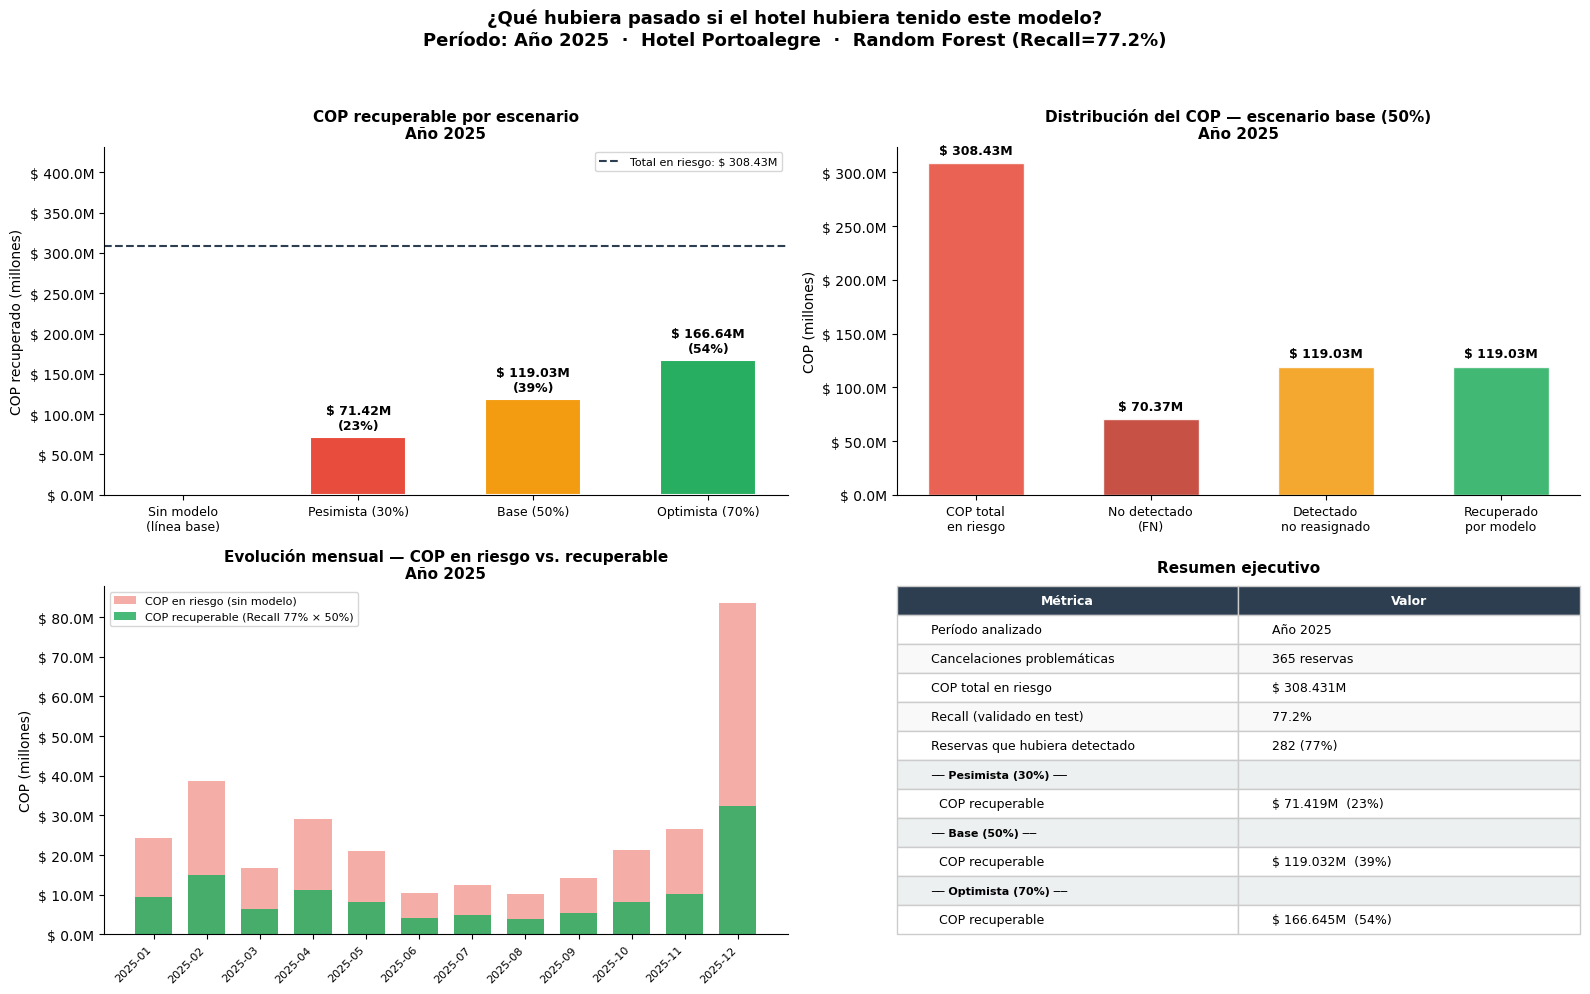


✅ Gráfico guardado como 'simulacion_contrafactual_Año_2025.png'

══════════════════════════════════════════════════════════════════
  RESPUESTA A LA GERENCIA (Año 2025):
  Si el hotel hubiera contado con este modelo en Año 2025,
  habría identificado el 77% de las 365 cancelaciones
  problemáticas (282 reservas alertadas a tiempo).
  Dependiendo de la capacidad de reasignación operativa:
    • Pesimista (30%)          : $   71,419,234  (23% del total en riesgo)
    • Base (50%)               : $  119,032,057  (39% del total en riesgo)
    • Optimista (70%)          : $  166,644,880  (54% del total en riesgo)
  sobre un total de $ 308,431,131 en riesgo.
══════════════════════════════════════════════════════════════════


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 11. SIMULACIÓN HISTÓRICA CONTRAFACTUAL — IMPACTO ECONÓMICO POR PERÍODO
# Hotel Portoalegre · Golfo de Morrosquillo
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from IPython.display import display

# ╔══════════════════════════════════════════════════════════════════╗
# ║  PARÁMETROS — ajusta aquí según el período que quieres analizar  ║
# ╠══════════════════════════════════════════════════════════════════╣
ANIO_ANALISIS  = 2025        # año a analizar  (None = todo el histórico)
FECHA_INICIO   = None        # ej. '2025-01-01'  (None = sin límite inferior)
FECHA_FIN      = None        # ej. '2025-12-31'  (None = sin límite superior)
# Si ANIO_ANALISIS está definido, tiene prioridad sobre FECHA_INICIO/FECHA_FIN
# ╚══════════════════════════════════════════════════════════════════╝

# ── 1. Recall y modelo seleccionado (vienen de celdas anteriores) ─────────────
recall_contrafactual = recall_final
mejor_modelo_nombre  = MEJOR_NOMBRE

# ── 2. Preparar dataset y aplicar filtro de período ───────────────────────────
df_hist = df.copy()
df_hist['Fecha cancelación'] = pd.to_datetime(
    df_hist['Fecha cancelación'], dayfirst=True, errors='coerce'
)

mask_prob = df_hist['target'] == 1

if ANIO_ANALISIS is not None:
    mask_periodo = df_hist['Fecha cancelación'].dt.year == ANIO_ANALISIS
    label_periodo = f"Año {ANIO_ANALISIS}"
elif FECHA_INICIO is not None or FECHA_FIN is not None:
    mask_periodo = pd.Series(True, index=df_hist.index)
    if FECHA_INICIO:
        mask_periodo &= df_hist['Fecha cancelación'] >= FECHA_INICIO
    if FECHA_FIN:
        mask_periodo &= df_hist['Fecha cancelación'] <= FECHA_FIN
    label_periodo = f"{FECHA_INICIO or 'inicio'} → {FECHA_FIN or 'hoy'}"
else:
    mask_periodo = pd.Series(True, index=df_hist.index)
    label_periodo = "Histórico completo (2023–2025)"

df_problematicas = df_hist[mask_prob & mask_periodo].copy()

# ── 3. Métricas base del período ──────────────────────────────────────────────
n_total      = len(df_problematicas)
cop_total    = df_problematicas['total_cop'].sum()
cop_promedio = df_problematicas['total_cop'].mean() if n_total > 0 else 0

print("╔══════════════════════════════════════════════════════════════════╗")
print(f"║  SIMULACIÓN CONTRAFACTUAL — {label_periodo:<36}║")
print("╚══════════════════════════════════════════════════════════════════╝")
print(f"  Modelo seleccionado               : {mejor_modelo_nombre}")
print(f"  Recall aplicado (validado en test): {recall_contrafactual:.1%}")
print(f"  Período analizado                 : {label_periodo}")
print(f"{'─'*66}")
print(f"  Cancelaciones problemáticas : {n_total:,} reservas")
print(f"  COP total en riesgo         : $ {cop_total:,.0f}")
print(f"  Valor promedio por reserva  : $ {cop_promedio:,.0f}")
print(f"{'─'*66}")

if n_total == 0:
    print("⚠  No hay cancelaciones problemáticas en el período seleccionado.")
    print("   Ajusta ANIO_ANALISIS o FECHA_INICIO / FECHA_FIN.")
else:
    # ── 4. Proyección de detección ────────────────────────────────────────────
    n_detectadas    = round(n_total * recall_contrafactual)
    n_no_detectadas = n_total - n_detectadas
    cop_detectado   = cop_total * recall_contrafactual
    cop_no_detectado = cop_total * (1 - recall_contrafactual)

    print(f"  DETECCIÓN (Recall = {recall_contrafactual:.1%}):")
    print(f"  Reservas alertadas          : {n_detectadas:,}  de {n_total:,}")
    print(f"  Reservas no detectadas      : {n_no_detectadas:,}  (pérdida inevitable)")
    print(f"  COP potencialmente alertado : $ {cop_detectado:,.0f}")

    # ── 5. Tres escenarios de reasignación operativa ──────────────────────────
    escenarios = {
        'Pesimista (30%)': 0.30,
        'Base (50%)':      0.50,
        'Optimista (70%)': 0.70,
    }
    colores_esc = {
        'Pesimista (30%)': '#E74C3C',
        'Base (50%)':      '#F39C12',
        'Optimista (70%)': '#27AE60',
    }

    print(f"\n{'═'*66}")
    print(f"  {'ESCENARIO':<25} {'Reservas':>10} {'COP Recuperado':>18} {'% del Total':>10}")
    print(f"{'─'*66}")

    res_esc = {}
    for nombre, p in escenarios.items():
        label = nombre.replace('\n', ' ')
        n_rec = round(n_detectadas * p)
        cop_r = cop_detectado * p
        pct   = cop_r / cop_total * 100 if cop_total > 0 else 0
        res_esc[nombre] = {'cop': cop_r, 'pct': pct, 'n': n_rec, 'p': p}
        print(f"  {label:<25} {n_rec:>10,} $ {cop_r:>15,.0f}   {pct:>7.1f}%")

    print(f"{'─'*66}")
    print(f"  {'Sin modelo (línea base)':<25} {'0':>10} $ {'0':>15}     0.0%")
    print(f"  {'COP total en riesgo':<25}         $ {cop_total:>15,.0f}   100.0%")
    print(f"{'═'*66}")

    # ── 6. Desglose mensual del período ──────────────────────────────────────
    df_problematicas['mes_periodo'] = (
        df_problematicas['Fecha cancelación'].dt.to_period('M').astype(str)
    )
    mensual = (df_problematicas.groupby('mes_periodo')['total_cop']
               .sum().reset_index())
    mensual.columns = ['Mes', 'COP_riesgo']
    mensual['COP_recuperable_base'] = mensual['COP_riesgo'] * recall_contrafactual * 0.50
    mensual = mensual.sort_values('Mes')

    # ── 7. Desglose por temporada (si existe) ─────────────────────────────────
    tiene_temporada = 'Temporada' in df_problematicas.columns
    if tiene_temporada:
        cop_temp = (df_problematicas.groupby('Temporada')['total_cop']
                    .agg(['sum','mean','count'])
                    .rename(columns={'sum':'COP Total','mean':'COP Promedio','count':'N Reservas'}))
        cop_temp['COP Recuperable (base 50%)'] = (
            cop_temp['COP Total'] * recall_contrafactual * 0.50
        )
        print(f"\n  DETALLE POR TEMPORADA — {label_periodo} (escenario base 50%):")
        display(cop_temp.style.format({
            'COP Total':                  '$ {:,.0f}',
            'COP Promedio':               '$ {:,.0f}',
            'N Reservas':                 '{:,}',
            'COP Recuperable (base 50%)': '$ {:,.0f}',
        }))

    # ── 8. VISUALIZACIÓN ─────────────────────────────────────────────────────
    n_rows = 3 if tiene_temporada else 2
    fig = plt.figure(figsize=(16, 5 * n_rows))
    fig.suptitle(
        f'¿Qué hubiera pasado si el hotel hubiera tenido este modelo?\n'
        f'Período: {label_periodo}  ·  Hotel Portoalegre  ·  '
        f'{mejor_modelo_nombre} (Recall={recall_contrafactual:.1%})',
        fontsize=13, fontweight='bold', y=0.99
    )

    # Panel 1 — Barras COP por escenario
    ax1 = fig.add_subplot(n_rows, 2, 1)
    labels_bar  = ['Sin modelo\n(línea base)'] + list(escenarios.keys())
    valores_bar = [0] + [res_esc[k]['cop'] for k in escenarios]
    colores_bar = ['#95A5A6'] + [colores_esc[k] for k in escenarios]

    bars1 = ax1.bar(range(len(labels_bar)), [v/1e6 for v in valores_bar],
                    color=colores_bar, width=0.55, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars1, valores_bar):
        if val > 0:
            pct_v = val / cop_total * 100
            ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+cop_total/1e6*0.02,
                     f'$ {val/1e6:.2f}M\n({pct_v:.0f}%)',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax1.axhline(cop_total/1e6, color='#2C3E50', linestyle='--', linewidth=1.5,
                label=f'Total en riesgo: $ {cop_total/1e6:.2f}M')
    ax1.set_xticks(range(len(labels_bar)))
    ax1.set_xticklabels(labels_bar, fontsize=9)
    ax1.set_ylabel('COP recuperado (millones)', fontsize=10)
    ax1.set_title(f'COP recuperable por escenario\n{label_periodo}',
                  fontsize=11, fontweight='bold')
    ax1.set_ylim(0, cop_total/1e6 * 1.40)
    ax1.legend(fontsize=8)
    ax1.spines[['top','right']].set_visible(False)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'$ {x:.1f}M'))

    # Panel 2 — Distribución del COP (escenario base)
    ax2 = fig.add_subplot(n_rows, 2, 2)
    p_base         = 0.50
    cop_rec_base   = cop_detectado * p_base
    cop_det_no_rea = cop_detectado * (1 - p_base)

    cats  = ['COP total\nen riesgo', 'No detectado\n(FN)', 'Detectado\nno reasignado', 'Recuperado\npor modelo']
    vals  = [cop_total/1e6, cop_no_detectado/1e6, cop_det_no_rea/1e6, cop_rec_base/1e6]
    cols  = ['#E74C3C', '#C0392B', '#F39C12', '#27AE60']
    bars2 = ax2.bar(range(4), vals, color=cols, alpha=0.88, width=0.55, edgecolor='white')
    for b, v in zip(bars2, vals):
        ax2.text(b.get_x()+b.get_width()/2, b.get_height()+cop_total/1e6*0.02,
                 f'$ {v:.2f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.set_xticks(range(4))
    ax2.set_xticklabels(cats, fontsize=9)
    ax2.set_ylabel('COP (millones)', fontsize=10)
    ax2.set_title(f'Distribución del COP — escenario base (50%)\n{label_periodo}',
                  fontsize=11, fontweight='bold')
    ax2.spines[['top','right']].set_visible(False)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'$ {x:.1f}M'))

    # Panel 3 — Evolución mensual
    ax3 = fig.add_subplot(n_rows, 2, 3)
    x_m = range(len(mensual))
    ax3.bar(x_m, mensual['COP_riesgo']/1e6, color='#E74C3C', alpha=0.45,
            label='COP en riesgo (sin modelo)', width=0.7)
    ax3.bar(x_m, mensual['COP_recuperable_base']/1e6, color='#27AE60', alpha=0.85,
            label=f'COP recuperable (Recall {recall_contrafactual:.0%} × 50%)', width=0.7)
    ax3.set_xticks(list(x_m))
    ax3.set_xticklabels(mensual['Mes'].tolist(), rotation=45, ha='right', fontsize=8)
    ax3.set_ylabel('COP (millones)', fontsize=10)
    ax3.set_title(f'Evolución mensual — COP en riesgo vs. recuperable\n{label_periodo}',
                  fontsize=11, fontweight='bold')
    ax3.legend(fontsize=8)
    ax3.spines[['top','right']].set_visible(False)
    ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'$ {x:.1f}M'))

    # Panel 4 — Tabla resumen
    ax4 = fig.add_subplot(n_rows, 2, 4)
    ax4.axis('off')
    keys_esc = list(escenarios.keys())
    tabla_data = [
        ['Métrica', 'Valor'],
        ['Período analizado',             label_periodo],
        ['Cancelaciones problemáticas',   f'{n_total:,} reservas'],
        ['COP total en riesgo',           f'$ {cop_total/1e6:.3f}M'],
        ['Recall (validado en test)',      f'{recall_contrafactual:.1%}'],
        ['Reservas que hubiera detectado',f'{n_detectadas:,} ({recall_contrafactual:.0%})'],
        ['── Pesimista (30%) ──',          ''],
        ['  COP recuperable',             f'$ {res_esc[keys_esc[0]]["cop"]/1e6:.3f}M  ({res_esc[keys_esc[0]]["pct"]:.0f}%)'],
        ['── Base (50%) ──',              ''],
        ['  COP recuperable',             f'$ {res_esc[keys_esc[1]]["cop"]/1e6:.3f}M  ({res_esc[keys_esc[1]]["pct"]:.0f}%)'],
        ['── Optimista (70%) ──',         ''],
        ['  COP recuperable',             f'$ {res_esc[keys_esc[2]]["cop"]/1e6:.3f}M  ({res_esc[keys_esc[2]]["pct"]:.0f}%)'],
    ]
    t = ax4.table(cellText=tabla_data[1:], colLabels=tabla_data[0],
                  cellLoc='left', loc='center', bbox=[0, 0, 1, 1])
    t.auto_set_font_size(False); t.set_fontsize(9)
    for (row, col), cell in t.get_celld().items():
        cell.set_edgecolor('#CCCCCC')
        if row == 0:
            cell.set_facecolor('#2C3E50'); cell.set_text_props(color='white', fontweight='bold')
        elif tabla_data[row][0].startswith('──'):
            cell.set_facecolor('#ECF0F1'); cell.set_text_props(fontweight='bold', fontsize=8)
        elif row % 2 == 0:
            cell.set_facecolor('#F9F9F9')
        else:
            cell.set_facecolor('white')
    ax4.set_title('Resumen ejecutivo', fontsize=11, fontweight='bold', pad=10)

    # Panel 5 — Barras por temporada (si existe)
    if tiene_temporada:
        ax5 = fig.add_subplot(n_rows, 2, (5, 6))
        temporadas = cop_temp.index.tolist()
        x_t = range(len(temporadas))
        w = 0.30
        b1 = ax5.bar([i - w/2 for i in x_t],
                     cop_temp['COP Total']/1e6,
                     width=w, color='#E74C3C', alpha=0.75, label='COP total en riesgo')
        b2 = ax5.bar([i + w/2 for i in x_t],
                     cop_temp['COP Recuperable (base 50%)']/1e6,
                     width=w, color='#27AE60', alpha=0.85, label='COP recuperable (base 50%)')
        for b, v in zip(b1, cop_temp['COP Total']/1e6):
            ax5.text(b.get_x()+b.get_width()/2, v + cop_total/1e6*0.01,
                     f'$ {v:.2f}M', ha='center', va='bottom', fontsize=8)
        for b, v in zip(b2, cop_temp['COP Recuperable (base 50%)']/1e6):
            ax5.text(b.get_x()+b.get_width()/2, v + cop_total/1e6*0.01,
                     f'$ {v:.2f}M', ha='center', va='bottom', fontsize=8, fontweight='bold')
        ax5.set_xticks(list(x_t)); ax5.set_xticklabels(temporadas, fontsize=10)
        ax5.set_ylabel('COP (millones)', fontsize=10)
        ax5.set_title(f'COP en riesgo vs. recuperable por temporada\n{label_periodo}',
                      fontsize=11, fontweight='bold')
        ax5.legend(fontsize=9); ax5.spines[['top','right']].set_visible(False)
        ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'$ {x:.1f}M'))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fname = f'simulacion_contrafactual_{label_periodo.replace(" ","_").replace("→","a")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"\n✅ Gráfico guardado como '{fname}'")

    # ── 9. Mensaje para la Gerencia ──────────────────────────────────────────
    print(f"\n{'═'*66}")
    print(f"  RESPUESTA A LA GERENCIA ({label_periodo}):")
    print(f"  Si el hotel hubiera contado con este modelo en {label_periodo},")
    print(f"  habría identificado el {recall_contrafactual:.0%} de las {n_total:,} cancelaciones")
    print(f"  problemáticas ({n_detectadas:,} reservas alertadas a tiempo).")
    print(f"  Dependiendo de la capacidad de reasignación operativa:")
    for nombre, d in res_esc.items():
        label_e = nombre.replace('\n', ' ')
        print(f"    • {label_e:<25}: $ {d['cop']:>12,.0f}  ({d['pct']:.0f}% del total en riesgo)")
    print(f"  sobre un total de $ {cop_total:,.0f} en riesgo.")
    print(f"{'═'*66}")

---
## 12. Proyección de Oportunidad Potencial Estimada — {ANIO_PROYECCION}

> **Estimación de potencial — no ingreso garantizado**
>
> El modelo identifica qué reservas tienen alta probabilidad de convertirse en cancelaciones problemáticas.
> El COP asociado a esas reservas representa la **oportunidad potencial máxima** de intervención.
> La recuperación efectiva depende de la capacidad operativa del hotel para reasignar
> las habitaciones alertadas antes del check-in — factor que está fuera del alcance del modelo.

**Cadena de cálculo:**

1. `COP_base` = COP total de cancelaciones problemáticas en el año base (dato histórico real)
2. `COP_proyectado` = `COP_base` × (1 + inflación proyectada)
3. `Oportunidad_potencial` = `COP_proyectado` × Recall del modelo

**Supuestos declarados (para validar con Gerencia):**
- Inflación proyectada: 2.50% (meta Banco de la República 2025–2026; de marzo 2026)
- Recall: valor validado en test — no se asume mejora ni degradación en producción
- Volumen de cancelaciones problemáticas crece proporcionalmente al ajuste de precios

╔══════════════════════════════════════════════════════════════════════╗
║  OPORTUNIDAD POTENCIAL ESTIMADA 2026                             ║
║  Estimación de potencial — no ingreso garantizado                    ║
╚══════════════════════════════════════════════════════════════════════╝

  SUPUESTOS DECLARADOS:
  ┌─────────────────────────────────────────────────────────────────┐
  │ Año base                  : 2025                                │
  │ Año proyectado            : 2026                                │
  │ Inflación aplicada        : 2.5%  (meta BanRep 2025-2026)   │
  │ Recall modelo             : 77.2%  (validado en test)        │
  │ Modelo seleccionado       : Random Forest                      │
  └─────────────────────────────────────────────────────────────────┘

  CADENA DE CÁLCULO:
  ──────────────────────────────────────────────────────────────────────
  [1] COP en riesgo 2025 (histórico real)
      = $    308,431,131

  [2] COP proyectado 2026 = COP_2025 × (1 

,Concepto,2025,2026,Δ
0,COP total en riesgo,"$ 308,431,131","$ 316,141,909",+2.5% (inflación proyectada)
1,Recall modelo (Random Forest),77.2%,77.2%,Sin cambio (supuesto conservador)
2,Oportunidad potencial estimada,"$ 238,064,114","$ 244,015,717",+2.5% (efecto inflación)
3,COP no identificado por modelo,"$ 70,367,017","$ 72,126,193",+2.5%


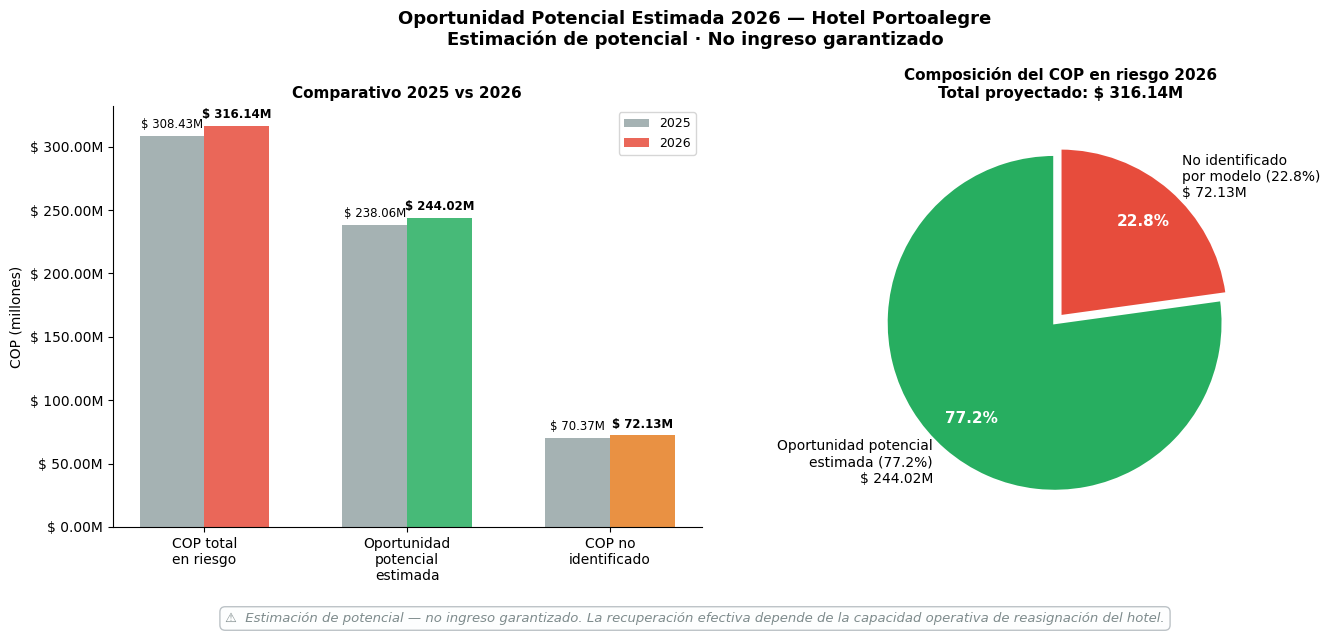


✅ Gráfico guardado como 'oportunidad_potencial_2026.png'

══════════════════════════════════════════════════════════════════════
  MENSAJE EJECUTIVO — OPORTUNIDAD POTENCIAL 2026
══════════════════════════════════════════════════════════════════════

  Si el hotel implementa el modelo en 2026, se estima que podría
  identificar el 77.2% de las cancelaciones problemáticas proyectadas,
  lo que representa una oportunidad potencial de:

  $      244,015,717 COP

  Este valor corresponde al 77.2% del COP proyectado en riesgo
  ($ 316,141,909), ajustado por una inflación del 2.5%
  sobre la base histórica 2025 ($ 308,431,131).

  ⚠  NOTA: Esta cifra es una estimación del potencial máximo de
     intervención, no un ingreso garantizado. La recuperación efectiva
     depende de la capacidad operativa del hotel para reasignar las
     habitaciones alertadas antes del check-in.

  SUPUESTOS (declarados para revisión de la Gerencia):
  [S1] Inflación 2.5% — meta Banco de la República 2025-2026
 

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 12. PROYECCIÓN DE OPORTUNIDAD POTENCIAL ESTIMADA
# Estimación de potencial — no ingreso garantizado
# Metodología: ajuste inflacionario sobre base histórica + Recall validado en test
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import pandas as pd
from IPython.display import display

# ╔══════════════════════════════════════════════════════════════════╗
# ║  PARÁMETROS — ajusta según criterio de la Gerencia               ║
# ╠══════════════════════════════════════════════════════════════════╣
ANIO_BASE        = 2025    # año base con datos reales
ANIO_PROYECCION  = 2026    # año a proyectar
INFLACION        = 0.025   # 2.5% — meta Banco República 2025-marzo 2026

# ╚══════════════════════════════════════════════════════════════════╝

# ── 1. Base histórica ─────────────────────────────────────────────────────────
df_hist2 = df.copy()
df_hist2['Fecha cancelación'] = pd.to_datetime(
    df_hist2['Fecha cancelación'], dayfirst=True, errors='coerce'
)
df_base = df_hist2[
    (df_hist2['target'] == 1) &
    (df_hist2['Fecha cancelación'].dt.year == ANIO_BASE)
].copy()

n_base    = len(df_base)
cop_base  = df_base['total_cop'].sum()

# ── 2. Proyección inflacionaria ───────────────────────────────────────────────
cop_proyectado = cop_base * (1 + INFLACION)

# ── 3. Oportunidad potencial = COP proyectado × Recall ───────────────────────
recall_proy          = recall_final
oportunidad_potencial = cop_proyectado * recall_proy
cop_no_identificado   = cop_proyectado * (1 - recall_proy)

# ── 4. Impresión de resultados ────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════════════╗")
print(f"║  OPORTUNIDAD POTENCIAL ESTIMADA {ANIO_PROYECCION}                             ║")
print(f"║  Estimación de potencial — no ingreso garantizado                    ║")
print("╚══════════════════════════════════════════════════════════════════════╝")
print()
print(f"  SUPUESTOS DECLARADOS:")
print(f"  ┌─────────────────────────────────────────────────────────────────┐")
print(f"  │ Año base                  : {ANIO_BASE}                                │")
print(f"  │ Año proyectado            : {ANIO_PROYECCION}                                │")
print(f"  │ Inflación aplicada        : {INFLACION*100:.1f}%  (meta BanRep 2025-2026)   │")
print(f"  │ Recall modelo             : {recall_proy:.1%}  (validado en test)        │")
print(f"  │ Modelo seleccionado       : {MEJOR_NOMBRE:<35}│")
print(f"  └─────────────────────────────────────────────────────────────────┘")
print()
print(f"  CADENA DE CÁLCULO:")
print(f"  {'─'*70}")
print(f"  [1] COP en riesgo {ANIO_BASE} (histórico real)")
print(f"      = $ {cop_base:>14,.0f}")
print()
print(f"  [2] COP proyectado {ANIO_PROYECCION} = COP_{ANIO_BASE} × (1 + {INFLACION*100:.1f}%)")
print(f"      = $ {cop_base:,.0f} × {1+INFLACION:.3f}")
print(f"      = $ {cop_proyectado:>14,.0f}")
print()
print(f"  [3] Oportunidad potencial = COP_{ANIO_PROYECCION} × Recall")
print(f"      = $ {cop_proyectado:,.0f} × {recall_proy:.3f}")
print(f"      = $ {oportunidad_potencial:>14,.0f}")
print(f"  {'─'*70}")
print()
print(f"  ┌─────────────────────────────────────────────────────────────────┐")
print(f"  │  OPORTUNIDAD POTENCIAL ESTIMADA {ANIO_PROYECCION}                         │")
print(f"  │                                                                   │")
print(f"  │  $ {oportunidad_potencial:>20,.0f} COP                           │")
print(f"  │  ({recall_proy:.1%} de $ {cop_proyectado:,.0f} en riesgo)          │")
print(f"  │                                                                   │")
print(f"  │  ⚠  Estimación de potencial — no ingreso garantizado             │")
print(f"  │     La recuperación efectiva depende de la capacidad             │")
print(f"  │     operativa de reasignación del equipo de recepción.           │")
print(f"  └─────────────────────────────────────────────────────────────────┘")

# ── 5. Tabla comparativa base vs proyección ───────────────────────────────────
print()
tabla = pd.DataFrame([
    {'Concepto': f'COP total en riesgo',
     str(ANIO_BASE): f'$ {cop_base:,.0f}',
     str(ANIO_PROYECCION): f'$ {cop_proyectado:,.0f}',
     'Δ': f'+{INFLACION*100:.1f}%  (inflación proyectada)'},
    {'Concepto': f'Recall modelo ({MEJOR_NOMBRE})',
     str(ANIO_BASE): f'{recall_proy:.1%}',
     str(ANIO_PROYECCION): f'{recall_proy:.1%}',
     'Δ': 'Sin cambio (supuesto conservador)'},
    {'Concepto': 'Oportunidad potencial estimada',
     str(ANIO_BASE): f'$ {cop_base*recall_proy:,.0f}',
     str(ANIO_PROYECCION): f'$ {oportunidad_potencial:,.0f}',
     'Δ': f'+{INFLACION*100:.1f}%  (efecto inflación)'},
    {'Concepto': 'COP no identificado por modelo',
     str(ANIO_BASE): f'$ {cop_base*(1-recall_proy):,.0f}',
     str(ANIO_PROYECCION): f'$ {cop_no_identificado:,.0f}',
     'Δ': f'+{INFLACION*100:.1f}%'},
])

display(
    tabla.style
    .set_caption(f'Comparativo de oportunidad potencial {ANIO_BASE} vs {ANIO_PROYECCION}')
    .set_properties(**{'text-align': 'left', 'font-size': '11px'})
    .apply(lambda x: ['background-color: #EBF5FB' if i == 2 else '' for i in range(len(x))], axis=0)
)

# ── 6. VISUALIZACIÓN ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f'Oportunidad Potencial Estimada {ANIO_PROYECCION} — Hotel Portoalegre\n'
    f'Estimación de potencial · No ingreso garantizado',
    fontsize=13, fontweight='bold'
)

# ─ Panel 1: Comparativo 2025 vs 2026 ─────────────────────────────────────────
ax1 = axes[0]
categorias = ['COP total\nen riesgo', 'Oportunidad\npotencial\nestimada', 'COP no\nidentificado']
vals_base  = [cop_base, cop_base*recall_proy, cop_base*(1-recall_proy)]
vals_proy  = [cop_proyectado, oportunidad_potencial, cop_no_identificado]

x1 = np.arange(len(categorias))
w1 = 0.32
b_base = ax1.bar(x1 - w1/2, [v/1e6 for v in vals_base],
                 width=w1, color='#95A5A6', alpha=0.85, label=str(ANIO_BASE))
b_proy = ax1.bar(x1 + w1/2, [v/1e6 for v in vals_proy],
                 width=w1,
                 color=['#E74C3C', '#27AE60', '#E67E22'],
                 alpha=0.85, label=str(ANIO_PROYECCION))

for b, v in zip(b_base, vals_base):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+cop_proyectado/1e6*0.012,
             f'$ {v/1e6:.2f}M', ha='center', va='bottom', fontsize=8.5)
for b, v in zip(b_proy, vals_proy):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+cop_proyectado/1e6*0.012,
             f'$ {v/1e6:.2f}M', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax1.set_xticks(x1)
ax1.set_xticklabels(categorias, fontsize=10)
ax1.set_ylabel('COP (millones)', fontsize=10)
ax1.set_title(f'Comparativo {ANIO_BASE} vs {ANIO_PROYECCION}', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines[['top','right']].set_visible(False)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'$ {x:.2f}M'))

# ─ Panel 2: Composición del COP proyectado 2026 ───────────────────────────────
ax2 = axes[1]
sizes  = [oportunidad_potencial, cop_no_identificado]
labels = [
    f'Oportunidad potencial\nestimada ({recall_proy:.1%})\n$ {oportunidad_potencial/1e6:.2f}M',
    f'No identificado\npor modelo ({1-recall_proy:.1%})\n$ {cop_no_identificado/1e6:.2f}M',
]
colors_pie = ['#27AE60', '#E74C3C']
explode    = (0.05, 0)

wedges, texts, autotexts = ax2.pie(
    sizes, labels=labels, colors=colors_pie, explode=explode,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 10},
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')

ax2.set_title(
    f'Composición del COP en riesgo {ANIO_PROYECCION}\n'
    f'Total proyectado: $ {cop_proyectado/1e6:.2f}M',
    fontsize=11, fontweight='bold'
)

# Nota de advertencia en el gráfico
fig.text(0.5, -0.04,
         '⚠  Estimación de potencial — no ingreso garantizado. '
         'La recuperación efectiva depende de la capacidad operativa de reasignación del hotel.',
         ha='center', fontsize=9.5, style='italic', color='#7F8C8D',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#FDFEFE', edgecolor='#BDC3C7'))

plt.tight_layout()
fname = f'oportunidad_potencial_{ANIO_PROYECCION}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\n✅ Gráfico guardado como '{fname}'")

# ── 7. Mensaje ejecutivo ──────────────────────────────────────────────────────
print(f"\n{'═'*70}")
print(f"  MENSAJE EJECUTIVO — OPORTUNIDAD POTENCIAL {ANIO_PROYECCION}")
print(f"{'═'*70}")
print()
print(f"  Si el hotel implementa el modelo en {ANIO_PROYECCION}, se estima que podría")
print(f"  identificar el {recall_proy:.1%} de las cancelaciones problemáticas proyectadas,")
print(f"  lo que representa una oportunidad potencial de:")
print()
print(f"  $ {oportunidad_potencial:>16,.0f} COP")
print()
print(f"  Este valor corresponde al {recall_proy:.1%} del COP proyectado en riesgo")
print(f"  ($ {cop_proyectado:,.0f}), ajustado por una inflación del {INFLACION*100:.1f}%")
print(f"  sobre la base histórica {ANIO_BASE} ($ {cop_base:,.0f}).")
print()
print(f"  ⚠  NOTA: Esta cifra es una estimación del potencial máximo de")
print(f"     intervención, no un ingreso garantizado. La recuperación efectiva")
print(f"     depende de la capacidad operativa del hotel para reasignar las")
print(f"     habitaciones alertadas antes del check-in.")
print()
print(f"  SUPUESTOS (declarados para revisión de la Gerencia):")
print(f"  [S1] Inflación {INFLACION*100:.1f}% — meta Banco de la República 2025-2026")
print(f"  [S2] Recall {recall_proy:.1%} estable — el modelo no mejora ni degrada en {ANIO_PROYECCION}")
print(f"  [S3] Volumen de cancelaciones crece proporcionalmente al ajuste de precios")
print(f"{'═'*70}")
